# Statistical Downscaling: Initial Data Exploration

**Study domain:** 24–38°N, 30–38°E (Eastern Mediterranean and Middle East)  
**Study period:** 1990–1999  
**Predictor dataset:** CMIP6 CESM2-WACCM historical simulation (~1° grid)  
**Target dataset:** ERA5-Land reanalysis (0.1° grid)  

This notebook documents the exploratory data analysis conducted prior to model development. All analysis functions are imported from the `src/` module package to ensure reproducibility and facilitate future extension to additional GCMs, variables, and time periods.

## 0. Environment Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_io import (
    load_era5_land, load_cmip6, to_celsius, align_calendars,
    build_paired_dataframe, seasonal_split, compute_global_daily_mean,
)
from src.spatial_ops import (
    compute_land_mask, assign_era5_to_cmip_cells,
    pixel_counts_per_cmip_cell, pixel_count_stats,
    compute_distance_to_cell_center,
)
from src import visualization as viz

DATA_DIR  = PROJECT_ROOT / 'data'
PLOT_DIR  = PROJECT_ROOT / 'plots'
PLOT_DIR.mkdir(exist_ok=True)

REGION = {'south': 24, 'north': 38, 'west': 30, 'east': 38}

# Set SKIP_HEAVY=True to skip slow scatter regression cells (~5 min each).
SKIP_HEAVY = True

print(f'Project root  : {PROJECT_ROOT}')
print(f'Data directory: {DATA_DIR}')
print(f'Plot directory: {PLOT_DIR}')
print(f'SKIP_HEAVY    : {SKIP_HEAVY}')


Project root  : /Users/shirke/Desktop/Thesis
Data directory: /Users/shirke/Desktop/Thesis/data
Plot directory: /Users/shirke/Desktop/Thesis/plots
SKIP_HEAVY    : True


## 1. Datasets

Two datasets are used in this analysis:

| Dataset | Variable | Period | Resolution | Calendar |
|---|---|---|---|---|
| ERA5-Land (target) | 2 m temperature (`t2m`) | 1990–1999 | 0.1° × 0.1° (~11 km) | Gregorian |
| CMIP6 CESM2-WACCM (predictor) | Near-surface air temperature (`tas`) | 1990–1999 | ~0.94° × 1.25° (~100 km) | No-leap |

Both datasets are loaded and converted from Kelvin to °C below.

In [2]:
# ── ERA5-Land: locate annual files ──────────────────────────────────────────
ERA5_LAND_FILES = sorted(
    [p for p in DATA_DIR.glob('t2m_ERA5land_daily_*.nc') if '(1)' not in p.name]
)
CMIP_FILE = DATA_DIR / 'tas_day_CESM2-WACCM_historical_r1i1p1f1_gn_19900101-19991231.nc'

manifest = pd.DataFrame(
    [
        {
            'Dataset': 'ERA5-Land',
            'Files found': len(ERA5_LAND_FILES),
            'Path pattern': str(DATA_DIR / 't2m_ERA5land_daily_YYYY.nc'),
            'Available': len(ERA5_LAND_FILES) > 0,
        },
        {
            'Dataset': 'CMIP6 CESM2-WACCM',
            'Files found': 1 if CMIP_FILE.exists() else 0,
            'Path pattern': str(CMIP_FILE),
            'Available': CMIP_FILE.exists(),
        },
    ]
)
manifest

,Dataset,Files found,Path pattern,Available
0,ERA5-Land,10,/Users/shirke/Desktop/Thesis/data/t2m_ERA5land...,True
1,CMIP6 CESM2-WACCM,1,/Users/shirke/Desktop/Thesis/data/tas_day_CESM...,True


In [3]:
# ── Load datasets ────────────────────────────────────────────────────────────
print('Loading ERA5-Land ...')
era5_land_ds = load_era5_land(ERA5_LAND_FILES, region=REGION, pad_lat=0.1, pad_lon=0.1)

print('Loading CMIP6 ...')
cmip_ds = load_cmip6(CMIP_FILE, region=REGION, pad_lat=1.0, pad_lon=1.5)

structure = pd.DataFrame([
    {
        'Dataset': 'ERA5-Land',
        'Dimensions': dict(era5_land_ds.dims),
        'Latitude range': f"{float(era5_land_ds.latitude.min()):.2f}° – {float(era5_land_ds.latitude.max()):.2f}°N",
        'Longitude range': f"{float(era5_land_ds.longitude.min()):.2f}° – {float(era5_land_ds.longitude.max()):.2f}°E",
        'Time steps': len(era5_land_ds.time),
    },
    {
        'Dataset': 'CMIP6',
        'Dimensions': dict(cmip_ds.dims),
        'Latitude range': f"{float(cmip_ds.lat.min()):.2f}° – {float(cmip_ds.lat.max()):.2f}°N",
        'Longitude range': f"{float(cmip_ds.lon.min()):.2f}° – {float(cmip_ds.lon.max()):.2f}°E",
        'Time steps': len(cmip_ds.time),
    },
])
structure

Loading ERA5-Land ...


Loading CMIP6 ...


,Dataset,Dimensions,Latitude range,Longitude range,Time steps
0,ERA5-Land,"{'time': 3652, 'latitude': 141, 'longitude': 81}",24.00° – 38.00°N,30.00° – 38.00°E,3652
1,CMIP6,"{'time': 3650, 'lat': 17, 'lon': 9, 'nbnd': 2}",23.09° – 38.17°N,28.75° – 38.75°E,3650


## 2. Main Statistics

Descriptive statistics for both datasets after loading, unit conversion, and calendar alignment. ERA5-Land statistics are computed over land pixels only (ocean cells are NaN). CMIP6 statistics cover all grid cells in the subsetted domain.

In [4]:
# ── Main Statistics ──────────────────────────────────────────────────────────
# Uses raw loaded datasets (before calendar alignment).
# ERA5-Land may include leap days here; CMIP6 uses no-leap.
from src.data_io import to_celsius

era5_t2m_raw = to_celsius(era5_land_ds['t2m'])
era5_vals    = era5_t2m_raw.values          # (time, lat, lon)

cmip_tas_raw = to_celsius(cmip_ds['tas'])
cmip_vals    = cmip_tas_raw.values          # (time, lat, lon)

# ERA5-Land: land pixels only (NaN = ocean)
era5_land_flat = era5_vals[~np.isnan(era5_vals)]
n_land_pixels  = int((~np.isnan(era5_vals[0])).sum())
total_pixels   = era5_vals.shape[1] * era5_vals.shape[2]
missing_frac   = 1.0 - n_land_pixels / total_pixels
n_era5_days    = era5_vals.shape[0]

# CMIP6: all cells
cmip_flat   = cmip_vals[np.isfinite(cmip_vals)]
n_cmip_days = cmip_vals.shape[0]

# Percentile levels
pct_levels = [25, 50, 75, 90]
era5_pcts  = np.percentile(era5_land_flat, pct_levels)
cmip_pcts  = np.percentile(cmip_flat,      pct_levels)

print("=" * 58)
print(f"{'Metric':<38} {'ERA5-Land':>9} {'CMIP6':>9}")
print("=" * 58)
print(f"{'Minimum (°C)':<38} {era5_land_flat.min():>9.1f} {cmip_flat.min():>9.1f}")
print(f"{'25th percentile (°C)':<38} {era5_pcts[0]:>9.1f} {cmip_pcts[0]:>9.1f}")
print(f"{'Median / 50th percentile (°C)':<38} {era5_pcts[1]:>9.1f} {cmip_pcts[1]:>9.1f}")
print(f"{'Mean (°C)':<38} {era5_land_flat.mean():>9.1f} {cmip_flat.mean():>9.1f}")
print(f"{'Std deviation (°C)':<38} {era5_land_flat.std():>9.1f} {cmip_flat.std():>9.1f}")
print(f"{'75th percentile (°C)':<38} {era5_pcts[2]:>9.1f} {cmip_pcts[2]:>9.1f}")
print(f"{'90th percentile (°C)':<38} {era5_pcts[3]:>9.1f} {cmip_pcts[3]:>9.1f}")
print(f"{'Maximum (°C)':<38} {era5_land_flat.max():>9.1f} {cmip_flat.max():>9.1f}")
print("-" * 58)
print(f"{'Time steps (days)':<38} {n_era5_days:>9d} {n_cmip_days:>9d}")
print(f"{'Land pixels in domain':<38} {n_land_pixels:>9,d} {'all cells':>9}")
print(f"{'Ocean / missing fraction':<38} {missing_frac:>9.1%} {'0.0%':>9}")
print("=" * 58)


Metric                                 ERA5-Land     CMIP6
Minimum (°C)                               -21.3     -14.7
25th percentile (°C)                        12.7      15.0
Median / 50th percentile (°C)               20.1      21.2
Mean (°C)                                   19.2      20.8
Std deviation (°C)                           8.7       7.9
75th percentile (°C)                        26.3      27.0
90th percentile (°C)                        29.7      31.1
Maximum (°C)                                40.6      41.5
----------------------------------------------------------
Time steps (days)                           3652      3650
Land pixels in domain                      7,683 all cells
Ocean / missing fraction                   32.7%      0.0%


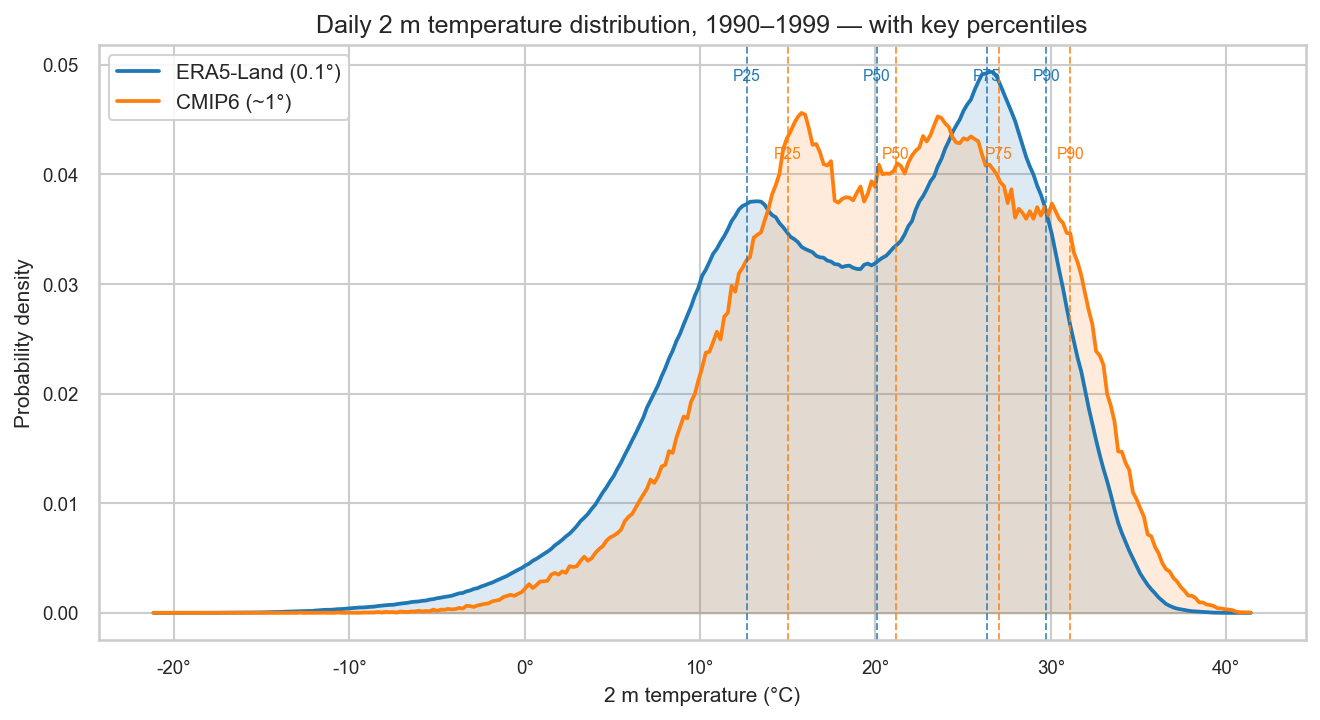

In [5]:
# ── Fig. 2a: Temperature distribution with percentiles ───────────────────────
fig = viz.plot_temperature_percentiles(
    era5_flat=era5_land_flat,
    cmip_flat=cmip_flat,
    percentiles=(25, 50, 75, 90),
    save_path=PLOT_DIR / 'fig02a_temperature_distribution.png',
)
plt.show()

**Fig. 2a.** Daily 2 m temperature distribution for ERA5-Land (blue, land pixels only) and CMIP6 CESM2-WACCM (orange, all domain cells), 1990–1999. Curves show probability density estimated from all pixel × day values. Dashed vertical lines mark the 25th, 50th, 75th, and 90th percentiles for each dataset; ERA5-Land labels appear near the top of the axes and CMIP6 labels below them. Data: ERA5-Land T2M and CMIP6 TAS, 24–38°N, 30–38°E.

## 3. Data Alignment & Preprocessing

### 3.1 Calendar harmonisation

ERA5-Land uses a Gregorian calendar (includes 29 February in leap years); CMIP6 CESM2-WACCM uses a no-leap calendar (365 days per year). The two ERA5-Land leap days within the study period (1992-02-29 and 1996-02-29) were removed, yielding a shared record of **3,650 days** spanning 1 January 1990 to 31 December 1999.

### 3.2 Unit conversion

Both datasets store temperature in Kelvin. Values were converted to °C by subtracting 273.15 K.

### 3.3 Land–sea mask and missing values

ERA5-Land provides data exclusively over land pixels; ocean grid cells are assigned NaN. Approximately **32.7%** of grid cells in the target domain are ocean. The missing-value pattern is spatially fixed: the same pixels are missing on every day in the record.

In [6]:
# ── Calendar alignment ───────────────────────────────────────────────────────
era5_aligned, cmip_aligned, shared_dates = align_calendars(era5_land_ds, cmip_ds)
print(f'Shared time steps : {len(shared_dates)}')
print(f'Period            : {shared_dates[0]} to {shared_dates[-1]}')

# ── Unit conversion ─────────────────────────────────────────────────────────
era5_temp = to_celsius(era5_aligned['t2m'])
cmip_tas  = to_celsius(cmip_aligned['tas'])

print(f'\nERA5-Land T2M  : min={float(era5_temp.min()):.1f}°C, '
      f'mean={float(era5_temp.mean()):.1f}°C, max={float(era5_temp.max()):.1f}°C')
print(f'CMIP6 TAS      : min={float(cmip_tas.min()):.1f}°C, '
      f'mean={float(cmip_tas.mean()):.1f}°C, max={float(cmip_tas.max()):.1f}°C')

# ── Land mask ────────────────────────────────────────────────────────────────
land_mask_2d = compute_land_mask(era5_temp)
missing_frac = 1.0 - land_mask_2d.mean()
print(f'\nLand pixels    : {land_mask_2d.sum():,d}')
print(f'Missing fraction (ocean): {missing_frac:.1%}')

Shared time steps : 3650
Period            : 1990-01-01 to 1999-12-31

ERA5-Land T2M  : min=-21.3°C, mean=19.2°C, max=40.6°C
CMIP6 TAS      : min=-14.7°C, mean=20.8°C, max=41.5°C

Land pixels    : 7,683
Missing fraction (ocean): 32.7%


## 4. Exploratory and Descriptive Analysis

### 4.1 Domain-averaged temporal variation

Domain-averaged daily temperature time series for both datasets reproduce the same unimodal annual seasonal cycle across the full decade, with a summer maximum of approximately 30–32°C (July–August) and a winter minimum of approximately 8–10°C (January–February). The CMIP6 domain mean (~20.5°C) is systematically higher than ERA5-Land (~19.2°C) by approximately 1–2°C across all months.

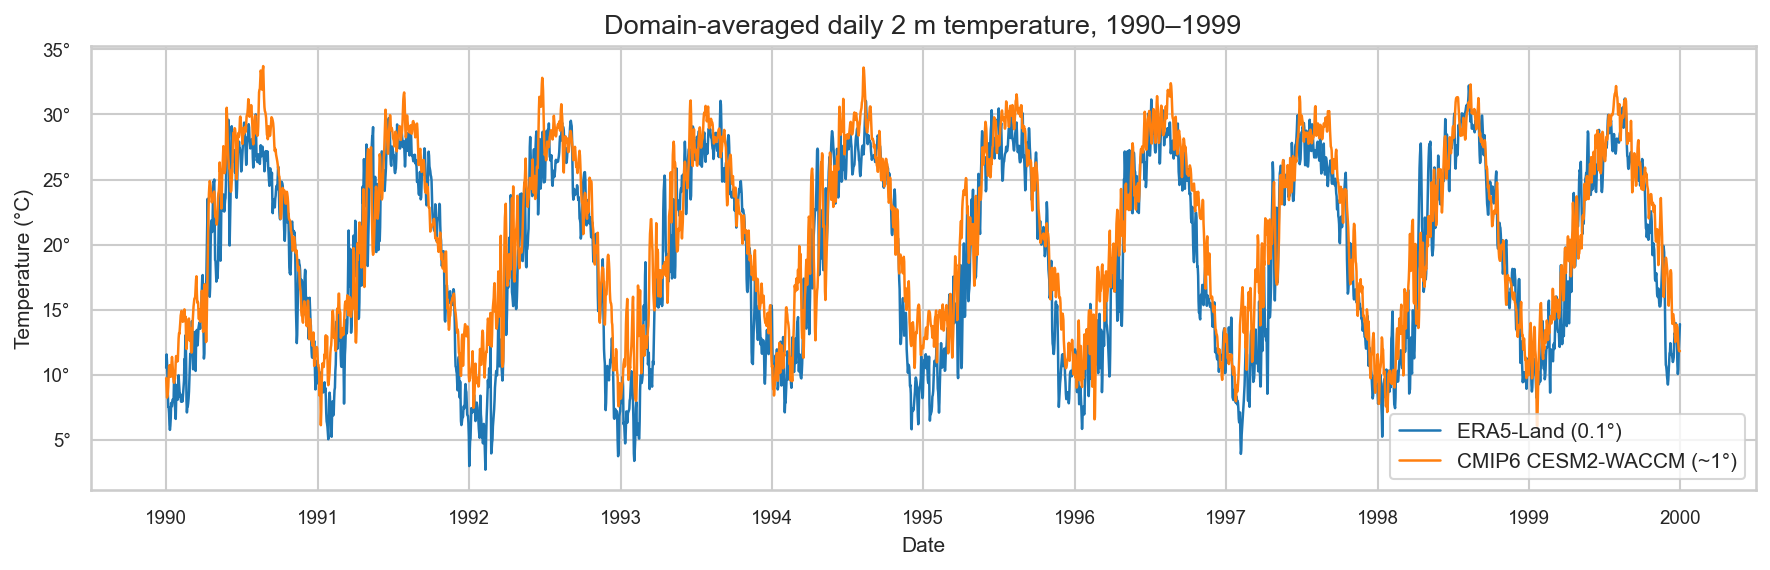

In [7]:
# Domain-averaged daily time series (full 1990–1999)
era5_series = era5_temp.mean(dim=['latitude', 'longitude'], skipna=True).to_series()
cmip_series = cmip_tas.mean(dim=['lat', 'lon'], skipna=True).to_series()

era5_series.index = pd.to_datetime(pd.Series(era5_series.index).astype(str), errors='coerce')
cmip_series.index = pd.to_datetime(pd.Series(cmip_series.index).astype(str), errors='coerce')

fig = viz.plot_domain_timeseries(
    {'ERA5-Land (0.1°)': era5_series, 'CMIP6 CESM2-WACCM (~1°)': cmip_series},
    title='Domain-averaged daily 2 m temperature, 1990–1999',
    save_path=PLOT_DIR / 'fig03a_domain_timeseries_full.png',
)
plt.show()

**Fig. 3a.** Domain-averaged daily 2 m temperature for ERA5-Land (0.1°, blue) and CMIP6 CESM2-WACCM (~1°, orange) over 1990–1999. Both datasets reproduce the same seasonal cycle in each year. The CMIP6 domain mean is systematically higher than ERA5-Land throughout the record, with the discrepancy most pronounced in late winter and early spring. Data: ERA5-Land (Copernicus CDS) and CMIP6 CESM2-WACCM historical simulation, study region 24–38°N, 30–38°E.

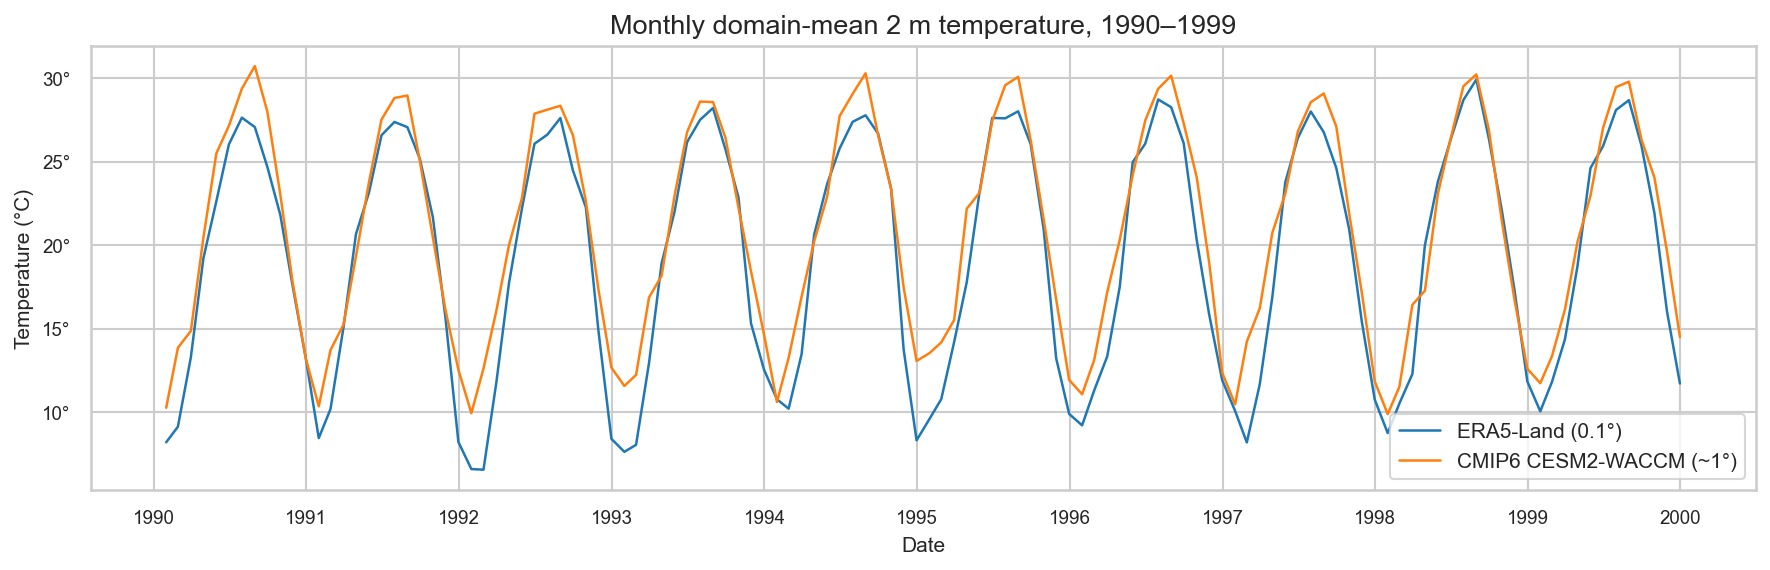

In [8]:
# Monthly aggregated timeseries (1 data point per month × year, 120 total)
era5_monthly = era5_series.resample("ME").mean()
cmip_monthly = cmip_series.resample("ME").mean()
era5_monthly.index = pd.to_datetime(era5_monthly.index.astype(str))
cmip_monthly.index = pd.to_datetime(cmip_monthly.index.astype(str))

fig = viz.plot_domain_timeseries(
    {'ERA5-Land (0.1°)': era5_monthly, 'CMIP6 CESM2-WACCM (~1°)': cmip_monthly},
    title='Monthly domain-mean 2 m temperature, 1990–1999',
    save_path=PLOT_DIR / 'fig03_monthly_trend.png',
)
plt.show()

**Fig. 3 (monthly trend).** Monthly domain-mean 2 m temperature, 1990–1999. Each point represents the area-averaged temperature for one calendar month, giving 120 data points (Jan 1990 → Dec 1999). Year-to-year variability within each season is visible. The systematic warm bias of CMIP6 CESM2-WACCM (~1–2°C) relative to ERA5-Land persists throughout the decade. Data: ERA5-Land T2M and CMIP6 TAS, 24–38°N, 30–38°E.

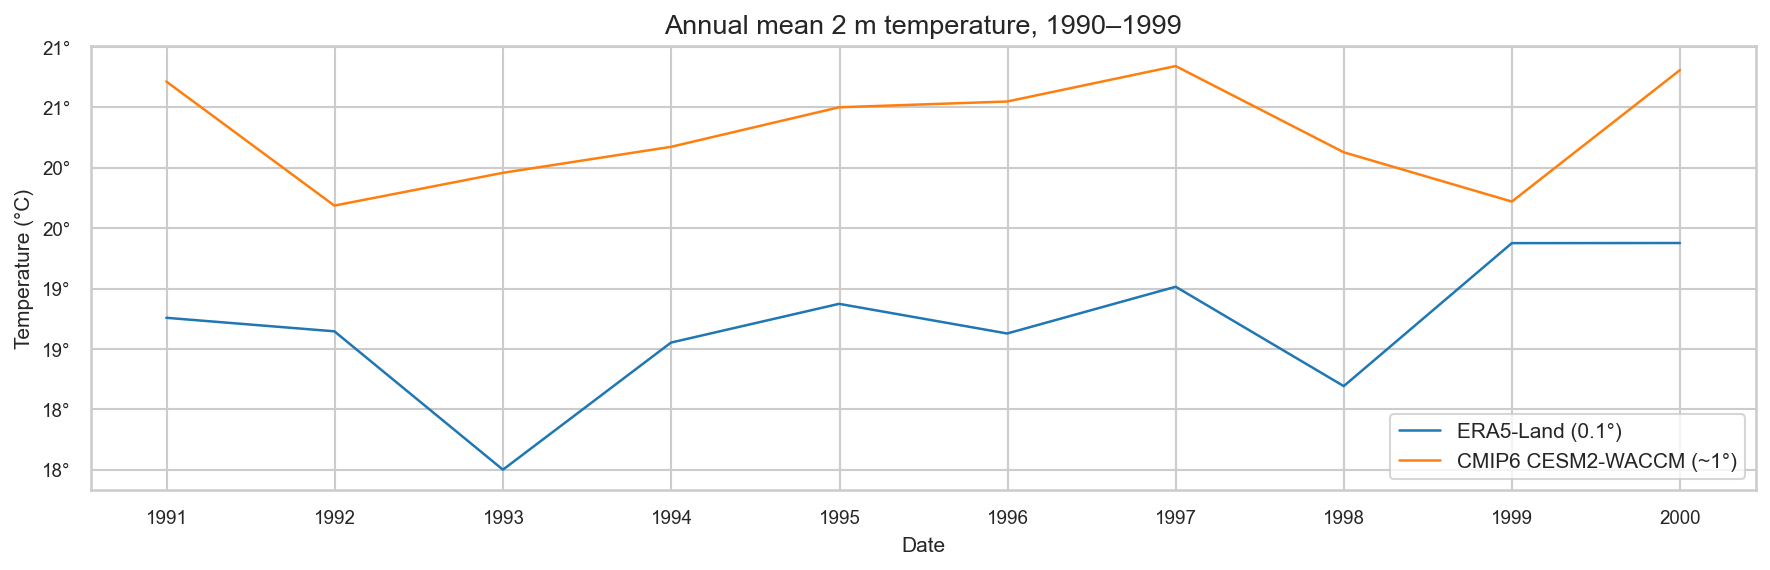

In [9]:
# Yearly aggregated timeseries (1 data point per year, 10 total)
era5_yearly = era5_series.resample("YE").mean()
cmip_yearly = cmip_series.resample("YE").mean()
era5_yearly.index = pd.to_datetime(era5_yearly.index.astype(str))
cmip_yearly.index = pd.to_datetime(cmip_yearly.index.astype(str))

fig = viz.plot_domain_timeseries(
    {'ERA5-Land (0.1°)': era5_yearly, 'CMIP6 CESM2-WACCM (~1°)': cmip_yearly},
    title='Annual mean 2 m temperature, 1990–1999',
    save_path=PLOT_DIR / 'fig03c_yearly_mean.png',
)
plt.show()


**Fig. 3c.** Annual mean domain-averaged 2 m temperature, 1990–1999. Each point represents the area-averaged temperature for one calendar year, giving 10 data points per dataset. The CMIP6 CESM2-WACCM model is consistently warmer than ERA5-Land by approximately 1–2°C in every year of the record. Data: ERA5-Land T2M and CMIP6 TAS, 24–38°N, 30–38°E.

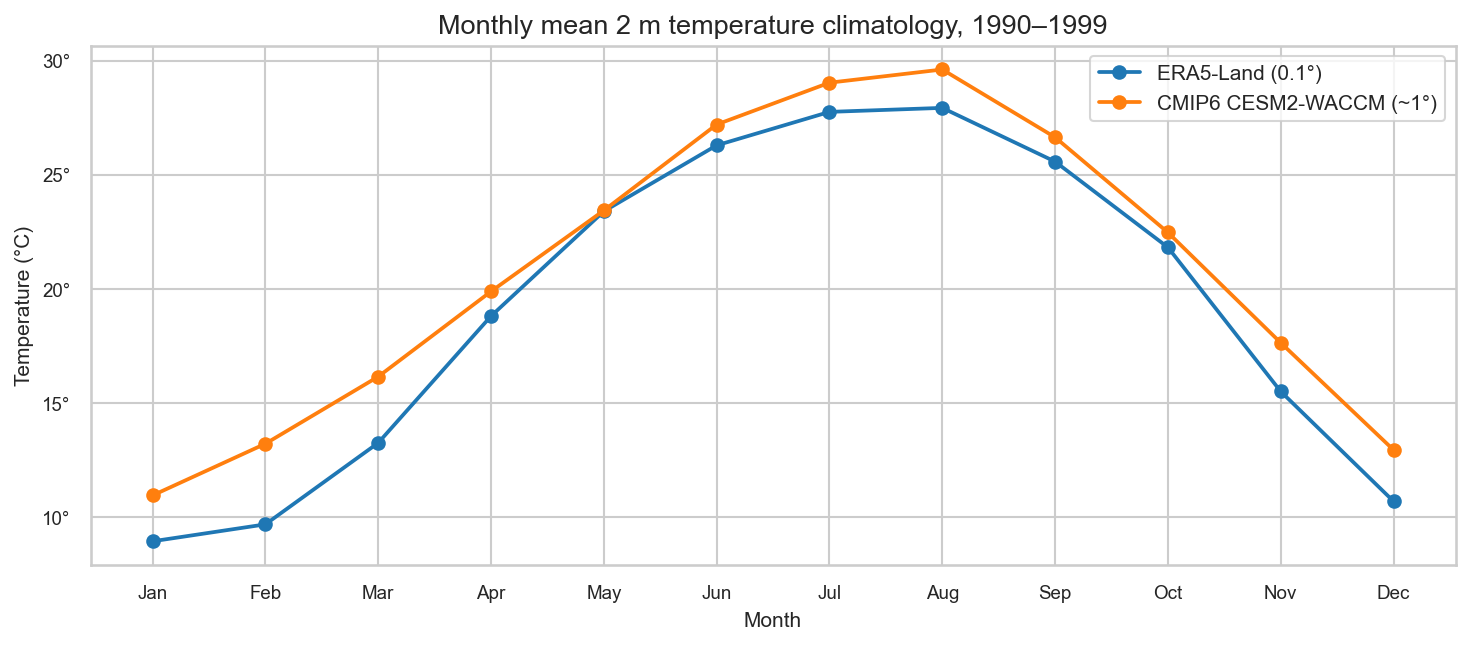

In [10]:
# Monthly mean climatology over the full period
fig = viz.plot_monthly_climatology(
    {'ERA5-Land (0.1°)': era5_series, 'CMIP6 CESM2-WACCM (~1°)': cmip_series},
    title='Monthly mean 2 m temperature climatology, 1990–1999',
    save_path=PLOT_DIR / 'fig03b_monthly_climatology.png',
)
plt.show()

**Fig. 3b.** Monthly mean 2 m temperature climatology averaged over the study domain (24–38°N, 30–38°E) for 1990–1999. Both datasets reproduce the same unimodal annual cycle, with a peak in July–August and a minimum in January–February. The CMIP6 CESM2-WACCM model exhibits a consistent warm bias of approximately 1–2°C relative to ERA5-Land, attributable to differences in land-surface parameterisation and spatial averaging at coarser resolution. Data: ERA5-Land and CMIP6 CESM2-WACCM historical simulation, 1990–1999.

### 4.2 Spatial overview: land/sea mask and temperature climatology

The ERA5-Land domain contains a static land–sea mask: ocean cells are always NaN. The binary map below shows which pixels contribute to the analysis. The mean temperature climatology (Fig. 2) then shows the spatial distribution of 2 m temperature over land.

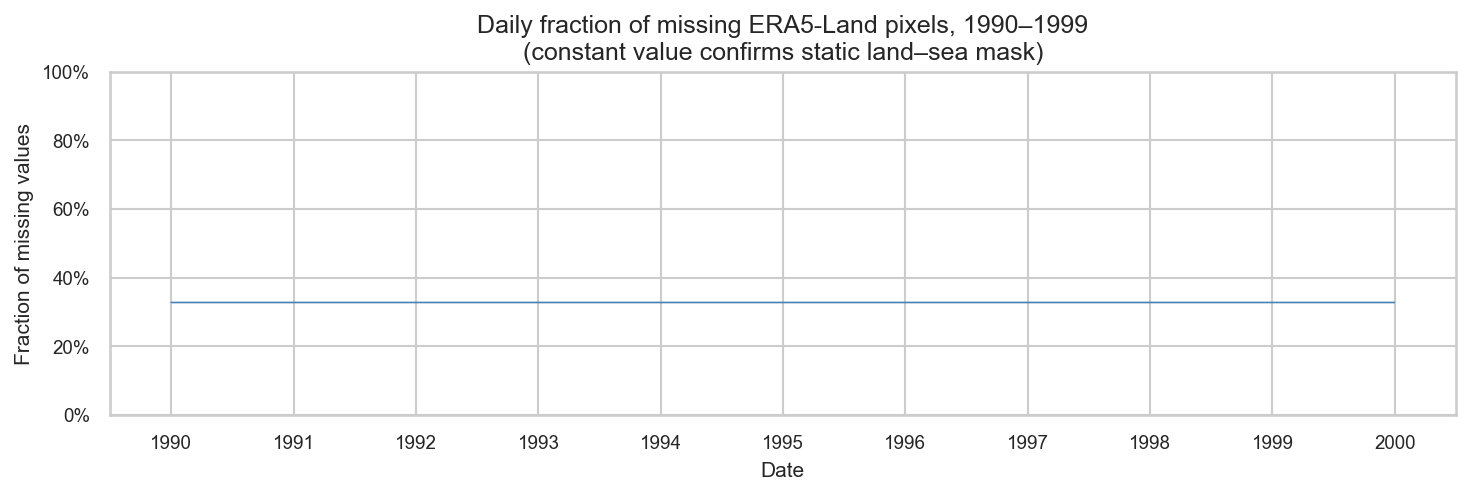

In [11]:
# Temporal pattern of missing values
missing_per_day = era5_temp.isnull().mean(dim=['latitude', 'longitude']).to_series()
missing_per_day.index = pd.to_datetime(
    pd.Series(missing_per_day.index).astype(str), errors='coerce'
)

fig = viz.plot_missing_fraction_timeseries(
    missing_per_day,
    save_path=PLOT_DIR / 'fig01a_missing_fraction_timeseries.png',
)
plt.show()

*Exploratory check — Fig. 1a.* Daily fraction of missing ERA5-Land pixels, 1990–1999. The fraction is perfectly constant at ~32.7% on every day, confirming a static land–sea mask (not a data quality issue).

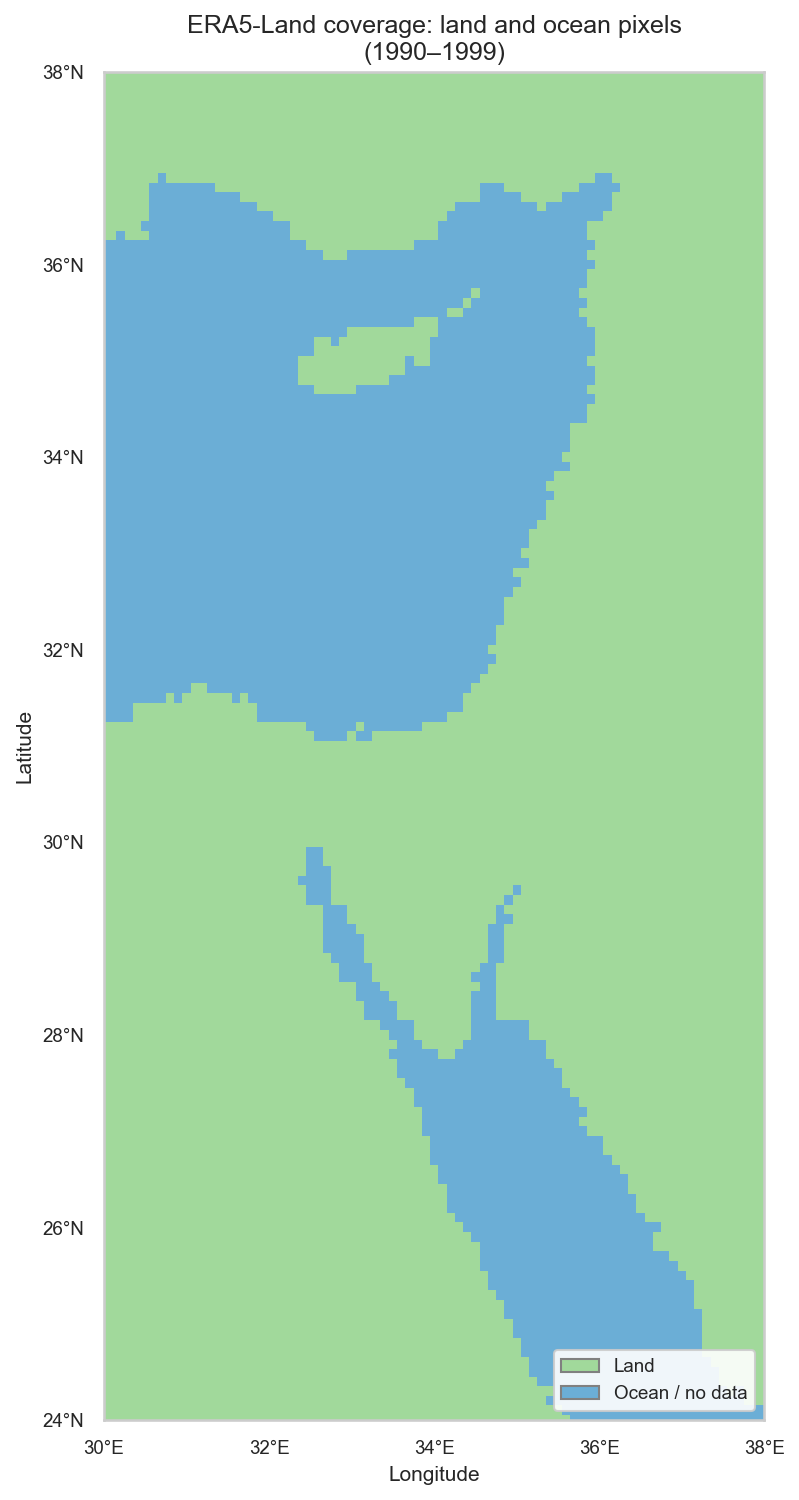

In [12]:
# ── Fig. 1b: Binary land/sea mask ───────────────────────────────────────────
era5_lats_plot = era5_temp.latitude.values
era5_lons_plot = era5_temp.longitude.values
land_mask_2d = ~np.isnan(era5_temp.mean(dim='time').values)

fig = viz.plot_land_sea_mask(
    land_mask_2d,
    lats=era5_lats_plot,
    lons=era5_lons_plot,
    save_path=PLOT_DIR / 'fig01b_land_sea_mask.png',
)
plt.show()

**Fig. 1b.** ERA5-Land land and ocean pixels, 1990–1999. Green pixels have valid temperature data (land); blue pixels are ocean grid cells with no ERA5-Land data. Approximately 32.7% of the study domain is ocean. The pattern is perfectly static: the same pixels are land on every day in the record. Data: ERA5-Land 2 m temperature, study region 24–38°N, 30–38°E.

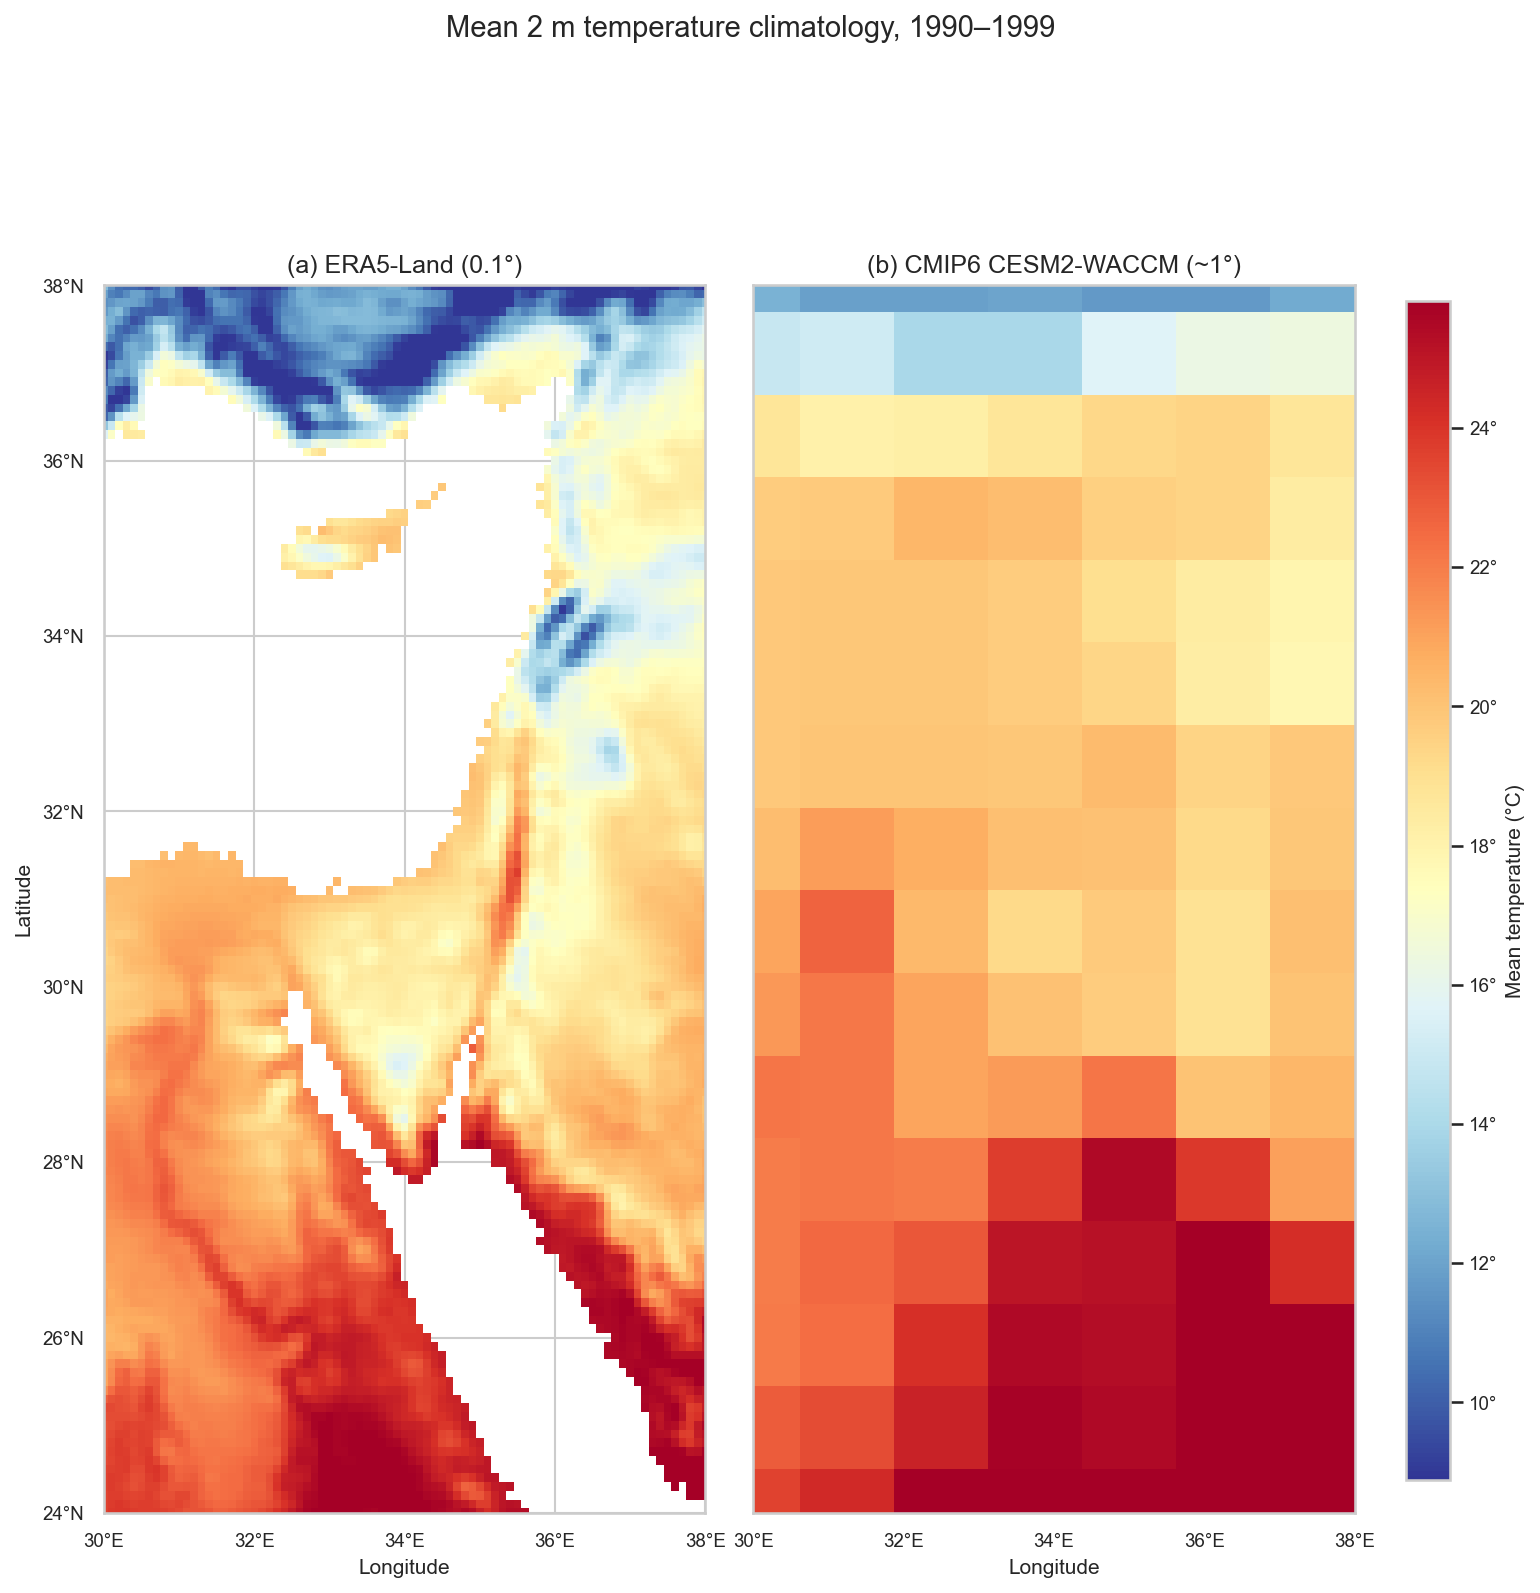

In [13]:
era5_mean_map = era5_temp.mean(dim='time').values
cmip_mean_map = cmip_tas.mean(dim='time').values

fig = viz.plot_side_by_side_maps(
    era5_mean_map, cmip_mean_map,
    era5_temp.latitude.values, era5_temp.longitude.values,
    cmip_tas.lat.values, cmip_tas.lon.values,
    titles=('ERA5-Land (0.1°)', 'CMIP6 CESM2-WACCM (~1°)'),
    suptitle='Mean 2 m temperature climatology, 1990–1999',
    cbar_label='Mean temperature (°C)',
    shared_clim=True,
    region=REGION,
    save_path=PLOT_DIR / 'fig02_temperature_climatology_comparison.png',
)
plt.show()

**Fig. 2.** Mean 2 m temperature climatology (1990–1999) for (a) ERA5-Land (0.1° resolution) and (b) CMIP6 CESM2-WACCM (~1° resolution), shown on a shared colour scale. Both datasets reproduce the same broad spatial gradient: highest mean temperatures over the Arabian Peninsula and lowest over the highlands of Turkey and the Levant. The coarser CMIP6 grid cannot resolve the fine-scale spatial heterogeneity apparent in ERA5-Land, particularly over complex terrain. Data: ERA5-Land and CMIP6 CESM2-WACCM historical simulation, study region 24–38°N, 30–38°E.

### 4.3 Seasonal temperature patterns

The four seasonal maps show ERA5-Land and CMIP6 side-by-side for DJF, MAM, JJA, and SON. The north–south gradient is strongest in summer (JJA) when the Arabian heat low dominates, and weakest in winter (DJF).

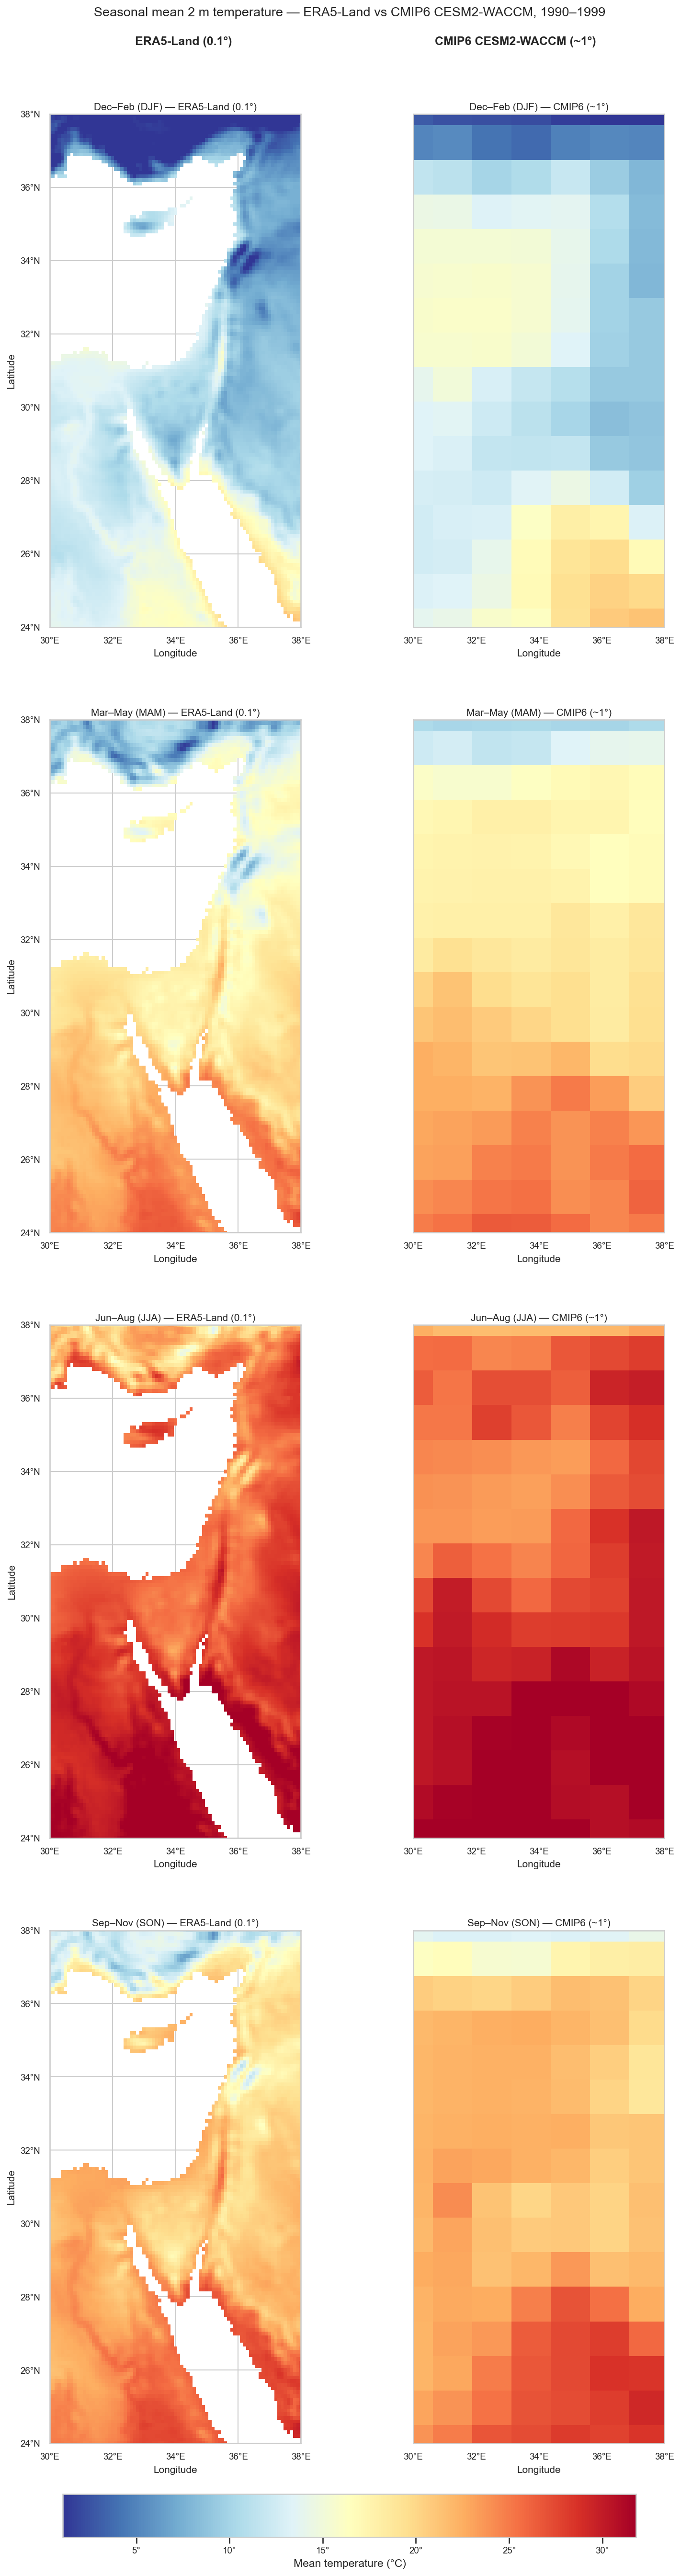

In [14]:
# Compute seasonal means for both datasets
era5_seasons = seasonal_split(era5_temp, time_dim='time')
era5_seasonal_means = {s: da.mean(dim='time').values for s, da in era5_seasons.items()}

cmip_seasons = seasonal_split(cmip_tas, time_dim='time')
cmip_seasonal_means = {s: da.mean(dim='time').values for s, da in cmip_seasons.items()}

fig = viz.plot_seasonal_comparison_maps(
    era5_seasonal_means, cmip_seasonal_means,
    era5_temp.latitude.values, era5_temp.longitude.values,
    cmip_tas.lat.values, cmip_tas.lon.values,
    region=REGION,
    save_path=PLOT_DIR / 'fig04_seasonal_comparison.png',
)
plt.show()

**Fig. 4.** Seasonal mean 2 m temperature, 1990–1999. Each row corresponds to one meteorological season: December–February (DJF), March–May (MAM), June–August (JJA), and September–November (SON). Left column: ERA5-Land (0.1°); right column: CMIP6 CESM2-WACCM (~1°). Both columns share the same colour scale. The summer season (JJA) is characterised by the highest temperatures and strongest north–south gradient. Topographic detail visible in ERA5-Land (e.g. mountain ranges in Turkey and Lebanon) is smoothed by the coarser CMIP6 grid. Data: ERA5-Land and CMIP6 CESM2-WACCM historical simulation, study region 24–38°N, 30–38°E.

### 4.4 Temperature distribution

The distribution of daily 2 m temperatures across all land pixels and all days shows that both datasets have broadly similar ranges. CMIP6 has a slightly higher median (consistent with the ~1–2°C warm bias) and narrower tails due to spatial averaging at the coarser resolution.

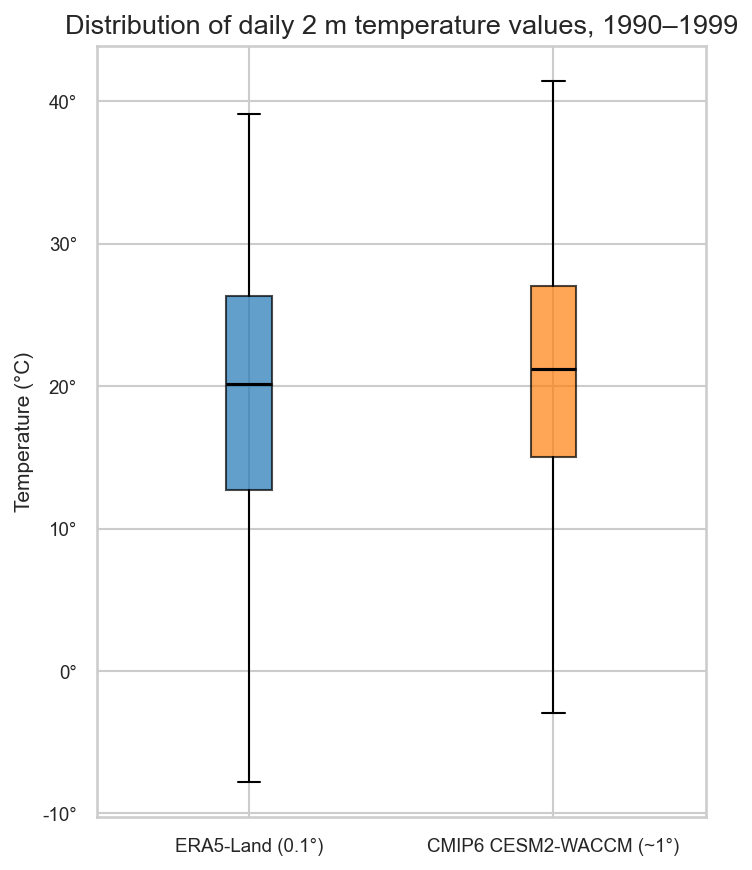

In [15]:
fig = viz.plot_temperature_distributions(
    {
        'ERA5-Land (0.1°)': era5_temp.values[~np.isnan(era5_temp.values)],
        'CMIP6 CESM2-WACCM (~1°)': cmip_tas.values.ravel(),
    },
    title='Distribution of daily 2 m temperature values, 1990–1999',
    save_path=PLOT_DIR / 'fig05_temperature_distributions.png',
)
plt.show()

**Fig. 5.** Distribution of daily 2 m temperature values for ERA5-Land (land pixels only) and CMIP6 CESM2-WACCM, 1990–1999. Boxes show the interquartile range (IQR; 25th–75th percentiles), whiskers extend to 1.5 × IQR, and outliers are omitted for clarity. The CMIP6 distribution is narrower than ERA5-Land, reflecting spatial averaging at coarser resolution and the absence of sub-grid topographic variability. Data: ERA5-Land and CMIP6 CESM2-WACCM historical simulation, study region 24–38°N, 30–38°E.

### 4.5 Warming trends

To investigate whether a temperature warming trend is detectable in this decade-long record, we examined domain-wide daily, monthly, and annual min/max temperature values. These exploratory checks (not shown in final figures) revealed no clear monotonic trend at the domain scale — the variability within each year far exceeds any decadal signal.

A warming signal only becomes visible when focusing on a **specific location and fixed calendar date**. The cell and date selected for this purpose are described below: the ERA5-Land pixel and CMIP6 cell closest to **35°E, 32°N** (central Levant / western Jordan), examined on **1 August** of each year (mid-summer, peak temperature season) and at the **quarterly dates** (1 Jan, 1 Apr, 1 Jul, 1 Oct).

In [16]:

# ── Exploratory: domain min/max temperature trends ─────────────────────────
# Compute the true spatial minimum and maximum across ALL domain pixels per day.
# For ERA5-Land: min/max across all land pixels (skipna=True excludes ocean NaN).
# For CMIP6: min/max across all 97 cells in the domain.
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

_c_era5 = '#1f77b4'   # tab10 blue  (ERA5-Land)
_c_cmip = '#ff7f0e'   # tab10 orange (CMIP6)
_temp_fmt = lambda x, pos: f"{int(x)}°"

# Daily spatial min/max (whole domain, 3650 values each)
era5_daily_min = era5_temp.min(dim=['latitude', 'longitude'], skipna=True).to_series()
era5_daily_max = era5_temp.max(dim=['latitude', 'longitude'], skipna=True).to_series()
cmip_daily_min = cmip_tas.min(dim=['lat', 'lon']).to_series()
cmip_daily_max = cmip_tas.max(dim=['lat', 'lon']).to_series()

# Convert indices to DatetimeIndex
era5_daily_min.index = pd.to_datetime(pd.Series(era5_daily_min.index).astype(str), errors='coerce')
era5_daily_max.index = pd.to_datetime(pd.Series(era5_daily_max.index).astype(str), errors='coerce')
cmip_daily_min.index = pd.to_datetime(pd.Series(cmip_daily_min.index).astype(str), errors='coerce')
cmip_daily_max.index = pd.to_datetime(pd.Series(cmip_daily_max.index).astype(str), errors='coerce')

print('ERA5 daily min range:', round(float(era5_daily_min.min()), 1), '→', round(float(era5_daily_min.max()), 1), '°C')
print('ERA5 daily max range:', round(float(era5_daily_max.min()), 1), '→', round(float(era5_daily_max.max()), 1), '°C')
print('CMIP6 daily min range:', round(float(cmip_daily_min.min()), 1), '→', round(float(cmip_daily_min.max()), 1), '°C')
print('CMIP6 daily max range:', round(float(cmip_daily_max.min()), 1), '→', round(float(cmip_daily_max.max()), 1), '°C')


ERA5 daily min range: -21.3 → 20.3 °C
ERA5 daily max range: 13.7 → 40.6 °C
CMIP6 daily min range: -14.7 → 26.6 °C
CMIP6 daily max range: 17.2 → 41.5 °C


#### Representative location: 35°E, 32°N

The ERA5-Land pixel and CMIP6 cell closest to longitude 35°E, latitude 32°N are identified below. This location (central Levant / western Jordan) was chosen as a representative inland mid-latitude site with good ERA5-Land coverage and minimal coastal influence.

In [17]:

# ── Select single pixel/cell closest to 35°E, 32°N ──────────────────────────
target_lon, target_lat = 35.0, 32.0

# ERA5-Land: find nearest pixel
era5_lat_idx = int(np.argmin(np.abs(era5_temp.latitude.values - target_lat)))
era5_lon_idx = int(np.argmin(np.abs(era5_temp.longitude.values - target_lon)))
chosen_era5_lat = float(era5_temp.latitude.values[era5_lat_idx])
chosen_era5_lon = float(era5_temp.longitude.values[era5_lon_idx])

# CMIP6: find nearest cell
cmip_lat_idx = int(np.argmin(np.abs(cmip_tas.lat.values - target_lat)))
cmip_lon_idx = int(np.argmin(np.abs(cmip_tas.lon.values - target_lon)))
chosen_cmip_lat = float(cmip_tas.lat.values[cmip_lat_idx])
chosen_cmip_lon = float(cmip_tas.lon.values[cmip_lon_idx])

print(f'Target location       : {target_lat}°N, {target_lon}°E')
print(f'Chosen ERA5-Land pixel: {chosen_era5_lat:.2f}°N, {chosen_era5_lon:.2f}°E')
print(f'Chosen CMIP6 cell     : {chosen_cmip_lat:.4f}°N, {chosen_cmip_lon:.4f}°E')

# Extract time series for the chosen pixel/cell
era5_pixel_ts = era5_temp.isel(latitude=era5_lat_idx, longitude=era5_lon_idx).to_series()
cmip_cell_ts  = cmip_tas.isel(lat=cmip_lat_idx, lon=cmip_lon_idx).to_series()

# Convert indices to DatetimeIndex
era5_pixel_ts.index = pd.to_datetime(pd.Series(era5_pixel_ts.index).astype(str), errors='coerce')
cmip_cell_ts.index  = pd.to_datetime(pd.Series(cmip_cell_ts.index).astype(str), errors='coerce')

print(f'\nERA5 pixel — mean: {era5_pixel_ts.mean():.1f}°C, '
      f'min: {era5_pixel_ts.min():.1f}°C, max: {era5_pixel_ts.max():.1f}°C')
print(f'CMIP6 cell — mean: {cmip_cell_ts.mean():.1f}°C, '
      f'min: {cmip_cell_ts.min():.1f}°C, max: {cmip_cell_ts.max():.1f}°C')


Target location       : 32.0°N, 35.0°E
Chosen ERA5-Land pixel: 32.00°N, 35.00°E
Chosen CMIP6 cell     : 31.5707°N, 35.0000°E

ERA5 pixel — mean: 19.7°C, min: 5.2°C, max: 32.5°C
CMIP6 cell — mean: 20.1°C, min: 4.7°C, max: 34.9°C


#### 1 August check: domain and single location, 1990–1999

To test detectability of a trend at a fixed calendar date, we extract values for 1 August in each of the 10 years. Panel (a) shows the domain-wide min and max; panel (b) shows the value at the chosen pixel/cell.

In [18]:

# ── Extract 1-August values for all 10 years ─────────────────────────────────
DATE_FILTER = '08-01'   # day-month format (1 August)

# Domain-wide min and max on 1 August each year
aug1_era5_min = era5_daily_min[era5_daily_min.index.strftime('%m-%d') == DATE_FILTER]
aug1_era5_max = era5_daily_max[era5_daily_max.index.strftime('%m-%d') == DATE_FILTER]
aug1_cmip_min = cmip_daily_min[cmip_daily_min.index.strftime('%m-%d') == DATE_FILTER]
aug1_cmip_max = cmip_daily_max[cmip_daily_max.index.strftime('%m-%d') == DATE_FILTER]

# Single pixel/cell value on 1 August each year
aug1_era5_pixel = era5_pixel_ts[era5_pixel_ts.index.strftime('%m-%d') == DATE_FILTER]
aug1_cmip_cell  = cmip_cell_ts[cmip_cell_ts.index.strftime('%m-%d') == DATE_FILTER]

# Report the extracted values
aug1_table = pd.DataFrame({
    'Year': aug1_era5_min.index.year,
    'ERA5 domain min': aug1_era5_min.values.round(1),
    'ERA5 domain max': aug1_era5_max.values.round(1),
    'CMIP6 domain min': aug1_cmip_min.values.round(1),
    'CMIP6 domain max': aug1_cmip_max.values.round(1),
    f'ERA5 pixel ({chosen_era5_lat:.1f}°N,{chosen_era5_lon:.1f}°E)': aug1_era5_pixel.values.round(1),
    f'CMIP6 cell ({chosen_cmip_lat:.1f}°N,{chosen_cmip_lon:.1f}°E)': aug1_cmip_cell.values.round(1),
})
aug1_table.set_index('Year', inplace=True)
print('1 August values for each year:')
aug1_table


1 August values for each year:


,ERA5 domain min,ERA5 domain max,CMIP6 domain min,CMIP6 domain max,"ERA5 pixel (32.0°N,35.0°E)","CMIP6 cell (31.6°N,35.0°E)"
Year,,,,,,
1990,14.800000,32.599998,23.400000,34.500000,25.799999,26.000000
1991,17.400000,32.500000,19.200001,36.299999,24.400000,25.799999
1992,11.500000,33.200001,21.299999,36.599998,26.200001,25.200001
1993,17.100000,35.900002,23.700001,36.099998,26.500000,26.900000
1994,10.600000,35.599998,20.700001,37.700001,24.900000,26.700001
1995,17.000000,37.799999,23.400000,36.000000,27.700001,26.200001
1996,17.200001,40.299999,23.200001,34.799999,27.400000,24.200001
1997,16.000000,32.500000,22.299999,34.700001,25.500000,27.000000
1998,18.000000,36.900002,20.299999,33.599998,28.799999,26.600000


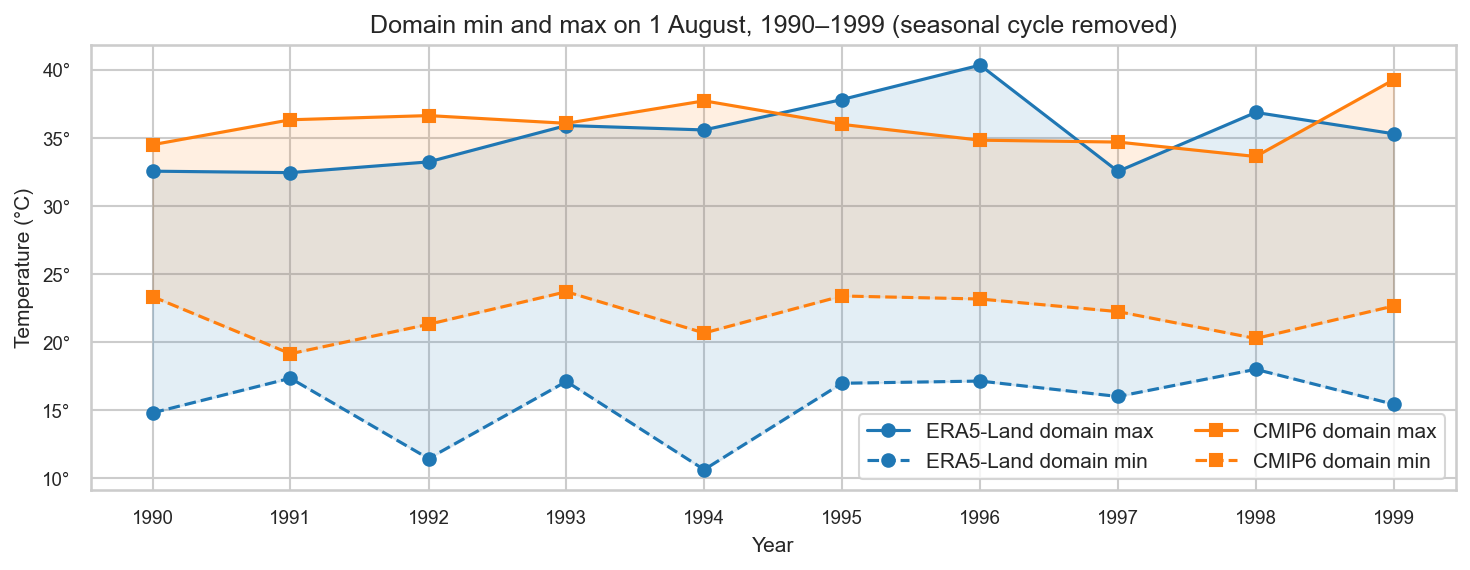

In [19]:

# ── Plot D: Domain min and max on 1 August across all years ──────────────────
years = aug1_era5_min.index

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(years, aug1_era5_max.values, lw=1.5, color=_c_era5, marker='o', ms=6,
        label='ERA5-Land domain max')
ax.plot(years, aug1_era5_min.values, lw=1.5, color=_c_era5, marker='o', ms=6,
        linestyle='--', label='ERA5-Land domain min')
ax.plot(years, aug1_cmip_max.values, lw=1.5, color=_c_cmip, marker='s', ms=6,
        label='CMIP6 domain max')
ax.plot(years, aug1_cmip_min.values, lw=1.5, color=_c_cmip, marker='s', ms=6,
        linestyle='--', label='CMIP6 domain min')
ax.fill_between(years, aug1_era5_min.values, aug1_era5_max.values,
                color=_c_era5, alpha=0.12)
ax.fill_between(years, aug1_cmip_min.values, aug1_cmip_max.values,
                color=_c_cmip, alpha=0.12)
ax.set_xticks(years)
ax.set_xticklabels(years.year, fontsize=9)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Temperature (°C)', fontsize=10)
ax.set_title('Domain min and max on 1 August, 1990–1999 (seasonal cycle removed)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(_temp_fmt))
ax.legend(framealpha=0.8, ncol=2)
plt.tight_layout()
fig.savefig(PLOT_DIR / 'fig10a_aug1_domain.png', bbox_inches='tight', dpi=150)
plt.show()



*Warming trends check — Plot D.* **Domain-wide min and max temperature on 1 August, 1990–1999.** Each year contributes one point per line. With the seasonal cycle removed, upward or downward trends in the 10 data points would indicate a year-over-year warming or cooling signal. The shaded band spans the domain min–max range on that date. Note that 10 years is a short period and individual year anomalies can dominate over any long-term trend.


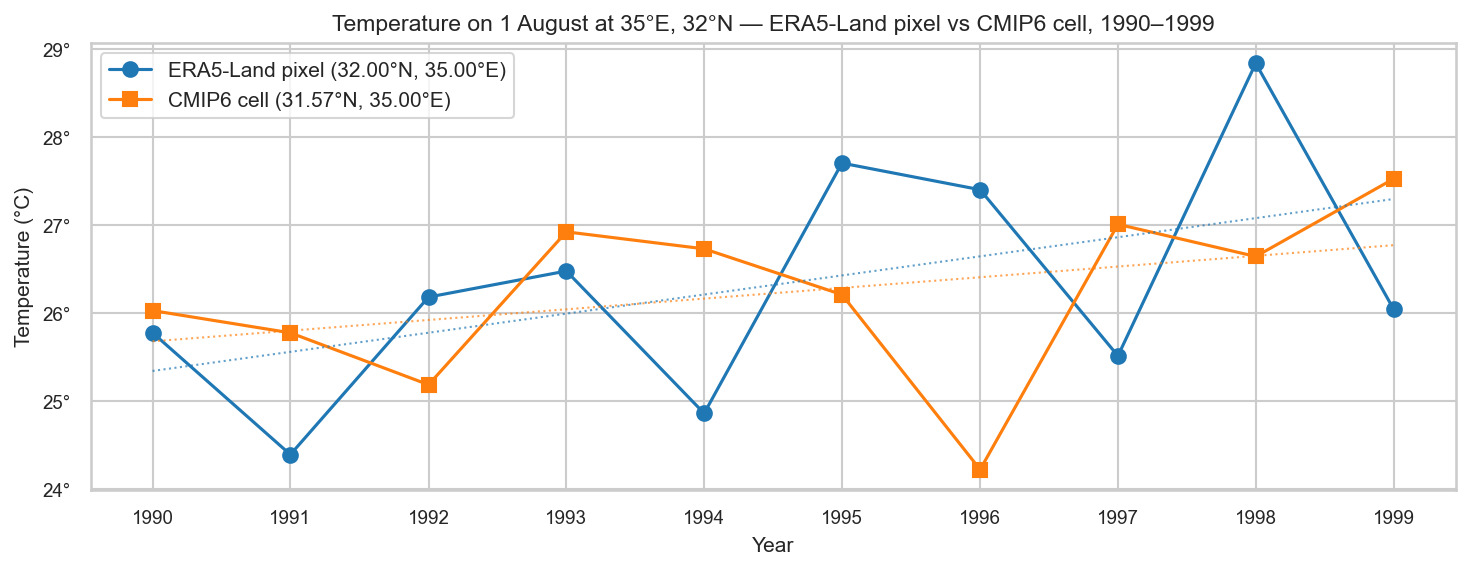

ERA5-Land pixel linear trend on 1 Aug: +0.217 °C/year
CMIP6 cell linear trend on 1 Aug     : +0.121 °C/year


In [20]:

# ── Plot E: Single pixel/cell value on 1 August across all years ─────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(years, aug1_era5_pixel.values, lw=1.5, color=_c_era5, marker='o', ms=7,
        label=f'ERA5-Land pixel ({chosen_era5_lat:.2f}°N, {chosen_era5_lon:.2f}°E)')
ax.plot(years, aug1_cmip_cell.values, lw=1.5, color=_c_cmip, marker='s', ms=7,
        label=f'CMIP6 cell ({chosen_cmip_lat:.2f}°N, {chosen_cmip_lon:.2f}°E)')

# OLS trend lines
yr_num = np.arange(len(years))
for vals, col in [(aug1_era5_pixel.values, _c_era5), (aug1_cmip_cell.values, _c_cmip)]:
    slope, intercept = np.polyfit(yr_num, vals, 1)
    ax.plot(years, slope * yr_num + intercept, lw=1.0, color=col, linestyle=':', alpha=0.7)

ax.set_xticks(years)
ax.set_xticklabels(years.year, fontsize=9)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Temperature (°C)', fontsize=10)
ax.set_title(f'Temperature on 1 August at 35°E, 32°N — ERA5-Land pixel vs CMIP6 cell, 1990–1999',
             fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(_temp_fmt))
ax.legend(framealpha=0.8)
plt.tight_layout()
fig.savefig(PLOT_DIR / 'fig10b_aug1_pixel.png', bbox_inches='tight', dpi=150)
plt.show()

slope_era5 = np.polyfit(yr_num, aug1_era5_pixel.values, 1)[0]
slope_cmip = np.polyfit(yr_num, aug1_cmip_cell.values, 1)[0]
print(f'ERA5-Land pixel linear trend on 1 Aug: {slope_era5:+.3f} °C/year')
print(f'CMIP6 cell linear trend on 1 Aug     : {slope_cmip:+.3f} °C/year')



*Warming trends check — Plot E.* **Temperature at 35°E, 32°N on 1 August, 1990–1999.** Each of the 10 points is the value for a single ERA5-Land pixel or CMIP6 cell on that exact date. Dotted lines show the OLS linear trend; the printed slope (°C/year) quantifies the direction and magnitude. A positive slope indicates warming on this date over the decade; a negative slope indicates cooling. With only 10 data points, the statistical significance of any detected trend is limited.


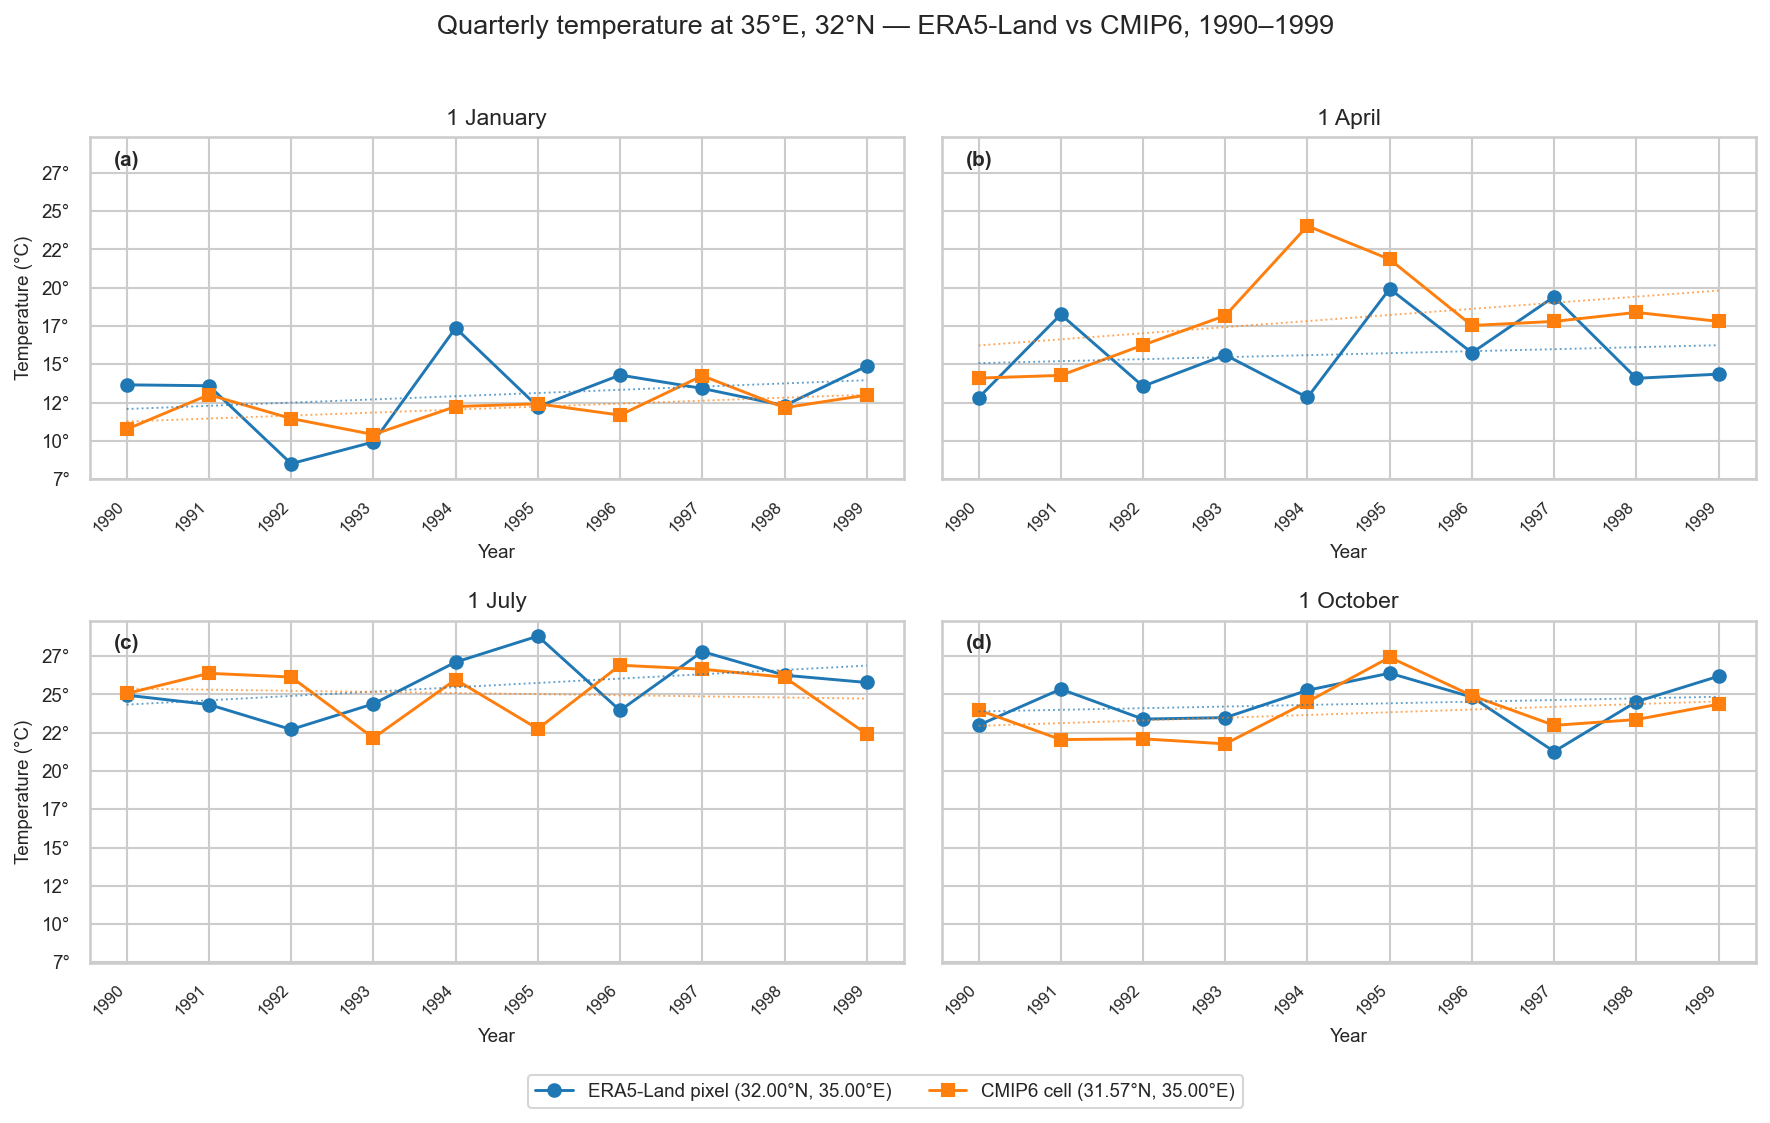

In [21]:

# ── Fig. 10: Quarterly warming trend at 35°E, 32°N ───────────────────────────
fig = viz.plot_quarterly_warming_trend(
    era5_ts=era5_pixel_ts,
    cmip_ts=cmip_cell_ts,
    era5_label=f'ERA5-Land pixel ({chosen_era5_lat:.2f}°N, {chosen_era5_lon:.2f}°E)',
    cmip_label=f'CMIP6 cell ({chosen_cmip_lat:.2f}°N, {chosen_cmip_lon:.2f}°E)',
    title=f'Quarterly temperature at 35°E, 32°N — ERA5-Land vs CMIP6, 1990–1999',
    save_path=PLOT_DIR / 'fig10_quarterly_warming_trend.png',
)
plt.show()



**Fig. 10.** Quarterly temperature at the location nearest to 35°E, 32°N, 1990–1999. Each panel shows values extracted on a fixed calendar date — (a) 1 January, (b) 1 April, (c) 1 July, (d) 1 October — for ERA5-Land (blue circles) and CMIP6 CESM2-WACCM (orange squares). Dotted lines show the OLS linear trend; with the seasonal cycle removed, any slope reflects year-over-year warming or cooling at that location and season. Data: ERA5-Land T2M and CMIP6 CESM2-WACCM TAS, study region 24–38°N, 30–38°E.


## 5. Pairing Mechanism

Each ERA5-Land land pixel (0.1°) is assigned to its nearest CMIP6 grid cell (~1°) using nearest-neighbour matching along the latitude and longitude axes independently. This yielded **97 unique CMIP6 cells** covering the study domain, each acting as the coarse-scale predictor for all fine-resolution pixels within it.

**Grid padding**: when subsetting the CMIP6 dataset, a padding of 1.0° in latitude and 1.5° in longitude was applied beyond the nominal domain boundaries to ensure that grid cells whose centres lie outside the domain but whose footprints overlap it are retained. Without padding, border ERA5 pixels near the domain edge would be assigned to cells whose centres fall outside the extraction window.

**Limitation of nearest-neighbour matching**: each ERA5 pixel is assigned to exactly one coarse cell, ignoring partial spatial overlaps with adjacent cells. Alternative methods (bilinear interpolation, area-weighted remapping) would better handle pixels near cell boundaries but add implementation complexity.

In [22]:
era5_lats = era5_temp.latitude.values
era5_lons = era5_temp.longitude.values
cmip_lats = cmip_tas.lat.values
cmip_lons = cmip_tas.lon.values

assignment_df = assign_era5_to_cmip_cells(
    era5_lats, era5_lons, cmip_lats, cmip_lons, land_mask_2d
)
stats = pixel_count_stats(assignment_df)

labels = {
    'n_cells':       'Unique CMIP6 cells',
    'n_land_pixels': 'Total ERA5 land pixels',
    'mean':          'Mean pixels per cell',
    'std':           'Std dev pixels per cell',
    'min':           'Minimum pixels per cell',
    'p25':           '25th percentile',
    'median':        'Median pixels per cell',
    'p75':           '75th percentile',
    'p90':           '90th percentile',
    'max':           'Maximum pixels per cell',
}
print('Nearest-neighbour assignment statistics')
print('─' * 46)
for k, label in labels.items():
    v = stats[k]
    fmt = f'{v:,.0f}' if isinstance(v, (int, float)) else str(v)
    print(f'  {label:<30}: {fmt}')


Nearest-neighbour assignment statistics
──────────────────────────────────────────────
  Unique CMIP6 cells            : 97
  Total ERA5 land pixels        : 7,683
  Mean pixels per cell          : 79
  Std dev pixels per cell       : 38
  Minimum pixels per cell       : 1
  25th percentile               : 52
  Median pixels per cell        : 97
  75th percentile               : 108
  90th percentile               : 120
  Maximum pixels per cell       : 130


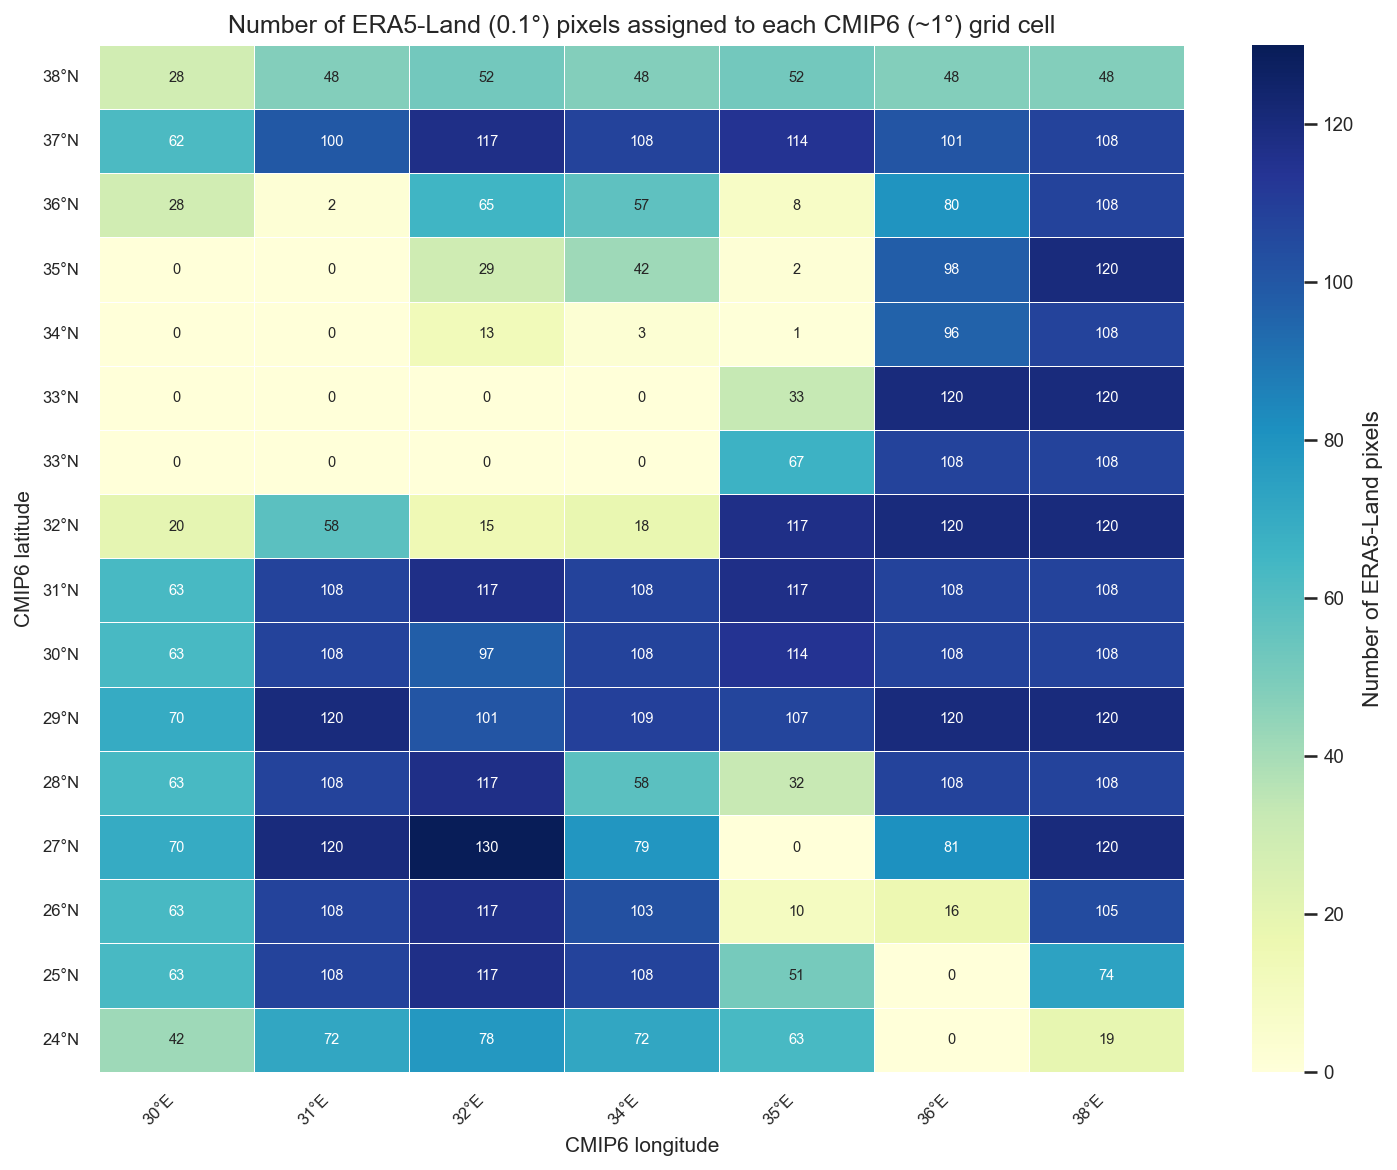

In [23]:
pixel_counts = pixel_counts_per_cmip_cell(assignment_df)
fig = viz.plot_pixels_per_cell_heatmap(
    pixel_counts,
    cmip_lats, cmip_lons,
    region=REGION,
    save_path=PLOT_DIR / 'fig06_pixels_per_cmip_cell.png',
)
plt.show()

**Fig. 6.** Number of ERA5-Land (0.1°) land pixels assigned to each CMIP6 CESM2-WACCM (~1°) grid cell via nearest-neighbour matching. CMIP6 cells positioned entirely over land receive the greatest number of ERA5-Land pixels, while coastal cells straddling the land–sea boundary receive fewer. Integer counts are annotated in each cell. Data: ERA5-Land and CMIP6 CESM2-WACCM spatial grids, study region 24–38°N, 30–38°E.

## 6. Coarse–Fine Temperature Relationship

The fundamental diagnostic for downscaling feasibility is the bivariate relationship between CMIP6 TAS and ERA5-Land T2M at matched grid cells. A strong linear relationship indicates that the coarse-resolution GCM field is a useful predictor of the fine-resolution target.

The paired pixel × day DataFrame built in Section 5 provides ~28 million (pixel, day) pairs linking each ERA5-Land land pixel to its assigned CMIP6 cell temperature on the same day.

In [24]:
print('Building paired pixel × day DataFrame (this may take ~1 min) ...')
paired_df = build_paired_dataframe(
    era5_temp, cmip_tas, assignment_df, land_mask_2d, shared_dates
)
print(f'Total rows: {len(paired_df):,d}')
print(f'Columns   : {list(paired_df.columns)}')
paired_df.head(3)

Building paired pixel × day DataFrame (this may take ~1 min) ...


Total rows: 28,042,950
Columns   : ['era5_lat', 'era5_lon', 'cmip_lat', 'cmip_lon', 'day', 't2m', 'tas']


,era5_lat,era5_lon,cmip_lat,cmip_lon,day,t2m,tas
0,38.0,30.0,38.167539,30.0,1990-01-01,1.659576,0.061005
1,38.0,30.1,38.167539,30.0,1990-01-01,1.156647,0.061005
2,38.0,30.2,38.167539,30.0,1990-01-01,0.739655,0.061005


In [25]:

if SKIP_HEAVY:
    print('Fig. 7 skipped (SKIP_HEAVY=True). Set SKIP_HEAVY=False in cell 0 to regenerate.')
else:
    fig = viz.plot_scatter_regression(
        paired_df,
        x_col='tas', y_col='t2m',
        title='CMIP6 CESM2-WACCM vs ERA5-Land: 2 m temperature',
        save_path=PLOT_DIR / 'fig07_scatter_regression.png',
    )
    plt.show()


Fig. 7 skipped (SKIP_HEAVY=True). Set SKIP_HEAVY=False in cell 0 to regenerate.


**Fig. 7.** Relationship between CMIP6 CESM2-WACCM near-surface air temperature (TAS, predictor) and ERA5-Land 2 m temperature (T2M, target). Panel (a): hexbin density plot of a random subsample of pixel × day pairs; panel (b): CMIP6 cell-mean TAS versus ERA5-Land cell-mean T2M with an ordinary least-squares (OLS) regression line (red). The Pearson correlation coefficient (*r*) is shown in the panel title. The 1:1 line (dashed black) is provided for reference. The non-zero OLS intercept reflects a systematic warm bias in CMIP6. The scatter around the regression line represents sub-grid spatial heterogeneity — the signal that the downscaling model aims to reconstruct. Data: ERA5-Land and CMIP6 CESM2-WACCM historical simulation, study region 24–38°N, 30–38°E, 1990–1999.

### 6.1 Residual diagnostics

In [26]:

if SKIP_HEAVY:
    print('Fig. 8 skipped (SKIP_HEAVY=True). Set SKIP_HEAVY=False in cell 0 to regenerate.')
else:
    dist_series = compute_distance_to_cell_center(assignment_df)
    dist_lookup = dict(zip(
        zip(assignment_df['era5_lat'], assignment_df['era5_lon']),
        dist_series.values,
    ))
    paired_df['dist_deg'] = [
        dist_lookup.get((lat, lon), np.nan)
        for lat, lon in zip(paired_df['era5_lat'], paired_df['era5_lon'])
    ]
    fig = viz.plot_residual_analysis(
        paired_df,
        save_path=PLOT_DIR / 'fig08_residual_analysis.png',
    )
    plt.show()


Fig. 8 skipped (SKIP_HEAVY=True). Set SKIP_HEAVY=False in cell 0 to regenerate.


**Fig. 8.** Residual diagnostics for the global OLS model (T2M ~ TAS). Panel (a): residuals plotted against CMIP6 TAS; a homogeneous spread around zero across the temperature range would indicate constant error variance (homoscedasticity). Panel (b): residuals plotted against Euclidean distance (°) from the assigned CMIP6 cell centre; the binned mean (black line) reveals whether the nearest-neighbour assignment introduces systematic bias for pixels far from cell centres. Data: ERA5-Land and CMIP6 CESM2-WACCM, study region 24–38°N, 30–38°E, 1990–1999 (random subsample of 100,000 pixel × day pairs).


### 6.2 Sea fraction and pixel count vs OLS residuals

Each CMIP6 cell may overlap both land and ocean in the ERA5-Land grid. Since ERA5-Land provides data only over land, cells with a high sea fraction carry a CMIP6 TAS value that averages over a mixture of land and ocean surface — which may systematically bias the downscaling residuals. Two separate figures test this hypothesis:

- **Fig. 11** — per-pixel mean OLS residual grouped by the sea fraction of the pixel's assigned CMIP6 cell (five equal-width bins, 0–100%).
- **Fig. 12** — same residuals grouped by the number of ERA5-Land land pixels per CMIP6 cell (five quantile-based bins).

For each ERA5-Land pixel the mean residual is computed as the average of (T2M − OLS prediction) over all 3,650 days. Note: the land–sea mask is static, so sea fraction is a time-independent geometric property of each cell.


In [27]:

from src.spatial_ops import compute_cell_sea_fraction

# Sea fraction per CMIP cell (static: land mask does not change with date)
sea_frac_df = compute_cell_sea_fraction(
    era5_lats=era5_temp.latitude.values,
    era5_lons=era5_temp.longitude.values,
    cmip_lats=cmip_tas.lat.values,
    cmip_lons=cmip_tas.lon.values,
    land_mask_2d=land_mask_2d,
)

# Land pixel count per CMIP cell (from existing assignment_df)
pix_counts = pixel_counts_per_cmip_cell(assignment_df).rename(
    columns={'n_pixels': 'n_land_pixels'}
)

# Merge into a single cell-level stats DataFrame
cell_stats_df = sea_frac_df.merge(pix_counts, on=['cmip_lat', 'cmip_lon'], how='left')
cell_stats_df['n_land_pixels'] = cell_stats_df['n_land_pixels'].fillna(0).astype(int)

print(f'Total CMIP6 cells with ERA5 coverage  : {len(cell_stats_df)}')
print(f'Cells with sea fraction > 0 (coastal) : {(cell_stats_df.sea_fraction > 0).sum()}')
print(f'Cells with sea fraction = 0 (all-land): {(cell_stats_df.sea_fraction == 0).sum()}')
print(f'Sea fraction range: {cell_stats_df.sea_fraction.min():.3f} – {cell_stats_df.sea_fraction.max():.3f}')
cell_stats_df.describe().round(2)


Total CMIP6 cells with ERA5 coverage  : 112
Cells with sea fraction > 0 (coastal) : 57
Cells with sea fraction = 0 (all-land): 55
Sea fraction range: 0.000 – 1.000


,cmip_lat,cmip_lon,n_total,n_land,n_sea,sea_fraction,n_land_pixels
count,112.00,112.00,112.00,112.00,112.00,112.00,112.00
mean,31.10,33.75,101.97,68.60,33.38,0.31,68.60
std,4.36,2.51,24.93,44.22,44.52,0.41,44.22
min,24.03,30.00,28.00,0.00,0.00,0.00,0.00
25%,27.57,31.25,100.50,28.00,0.00,0.00,28.00
50%,31.10,33.75,108.00,72.00,2.00,0.02,72.00
75%,34.63,36.25,120.00,108.00,63.75,0.73,108.00
max,38.17,37.50,130.00,130.00,130.00,1.00,130.00


In [28]:

# ── Compute pixel×day OLS residuals (shared by Fig. 11 and Fig. 12) ─────────
resid_df = viz.compute_ols_residuals(paired_df)
print(f"Residual rows: {len(resid_df):,}, "
      f"range: {resid_df['residual'].min():.1f} – {resid_df['residual'].max():.1f} °C")


Residual rows: 28,042,950, range: -29.6 – 22.2 °C


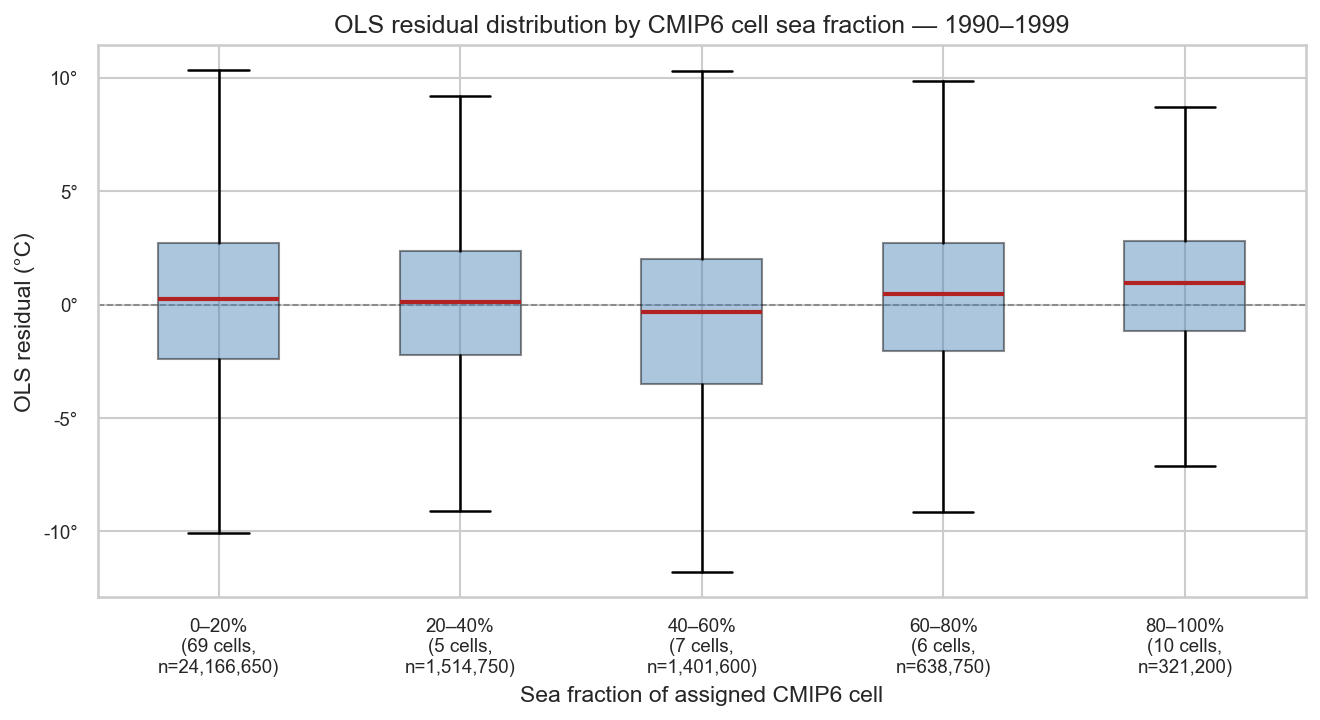

In [29]:

fig11 = viz.plot_residuals_by_sea_fraction(
    resid_df=resid_df,
    cell_stats_df=cell_stats_df,
    title="OLS residual distribution by CMIP6 cell sea fraction — 1990–1999",
    save_path=PLOT_DIR / "fig11_residuals_by_sea_fraction.png",
)
plt.show()



**Fig. 11.** OLS residual distribution by CMIP6 cell sea fraction, 1990–1999. Each box summarises the distribution of all pixel×day OLS residuals (ERA5-Land T2M minus OLS-predicted T2M) belonging to cells in that sea-fraction bin. The five bins span 0–20 % (predominantly land cells) to 80–100 % (predominantly ocean cells). The box spans the interquartile range; whiskers extend to 1.5 × IQR. A wider spread or shifted median in coastal bins would indicate that the mixed land–sea CMIP6 TAS value systematically distorts the downscaling prediction for land pixels. Data: ERA5-Land T2M and CMIP6 CESM2-WACCM TAS, 24–38°N, 30–38°E.


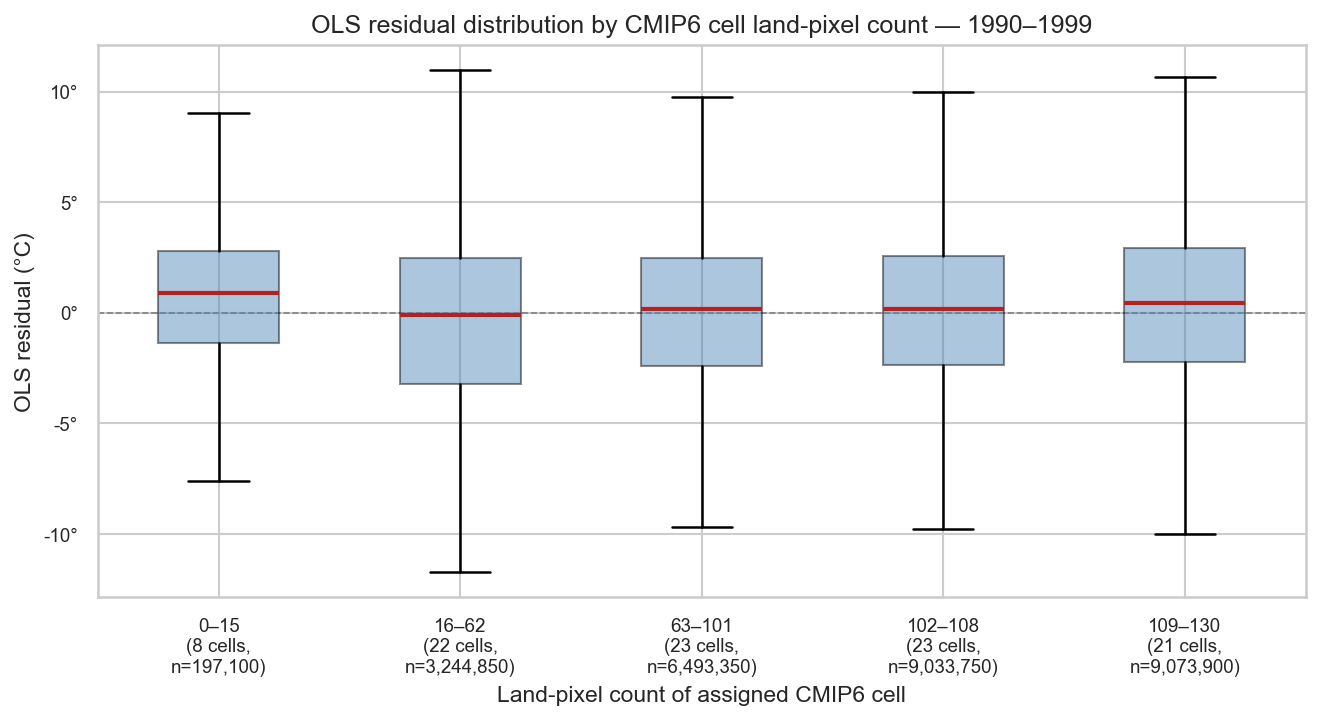

In [30]:

fig12 = viz.plot_residuals_by_pixel_count(
    resid_df=resid_df,
    cell_stats_df=cell_stats_df,
    title="OLS residual distribution by CMIP6 cell land-pixel count — 1990–1999",
    save_path=PLOT_DIR / "fig12_residuals_by_pixel_count.png",
)
plt.show()



**Fig. 12.** OLS residual distribution by CMIP6 cell land-pixel count, 1990–1999. The same pixel×day OLS residuals as in Fig. 11 are grouped into five quantile-based bins by the number of ERA5-Land land pixels assigned to each CMIP6 cell. Cells with few land pixels are typically coastal or domain-edge cells; cells with many pixels lie predominantly over flat inland terrain. A change in residual spread or median with increasing pixel count would indicate that data-sparse cells introduce systematic downscaling error. Data: ERA5-Land T2M and CMIP6 CESM2-WACCM TAS, 24–38°N, 30–38°E.


### 6.3 Temporal structure of OLS residuals: season and month

If the global OLS captures the relationship between CMIP6 TAS and ERA5-Land T2M well, residuals should be centred near zero in all seasons and months. Systematic seasonal shifts would indicate that a single linear fit is inadequate — for example, if the land–sea temperature contrast encoded in CMIP6 TAS differs between winter and summer, a global slope underestimates one season and overestimates the other.

**Fig. 13** groups residuals by meteorological season (DJF / MAM / JJA / SON); **Fig. 14** provides monthly resolution.

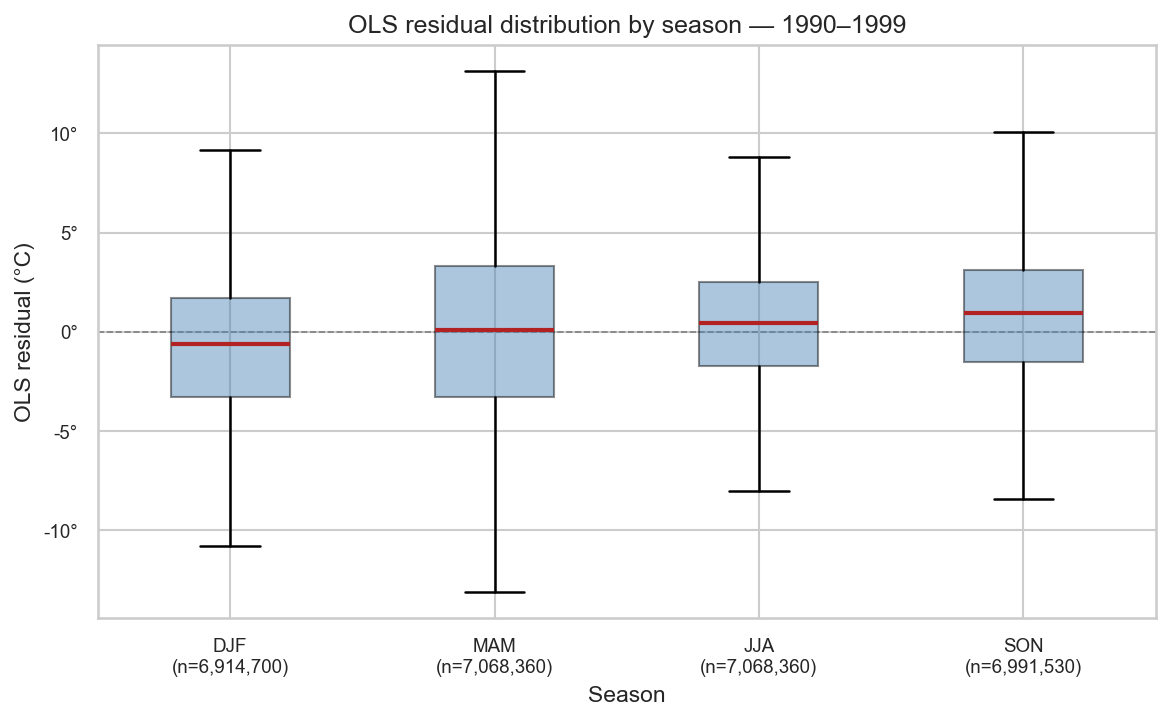

In [31]:
fig13 = viz.plot_residuals_by_season(
    resid_df=resid_df,
    title="OLS residual distribution by season — 1990–1999",
    save_path=PLOT_DIR / "fig13_residuals_by_season.png",
)
plt.show()


**Fig. 13.** OLS residual distribution by meteorological season, 1990–1999. Each box summarises all pixel×day residuals (ERA5-Land T2M minus OLS-predicted T2M) for that season across the full study domain. Outliers are suppressed for clarity. A median consistently above or below zero indicates a seasonal bias in the global OLS fit. Data: ERA5-Land T2M and CMIP6 CESM2-WACCM TAS, 24–38°N, 30–38°E.

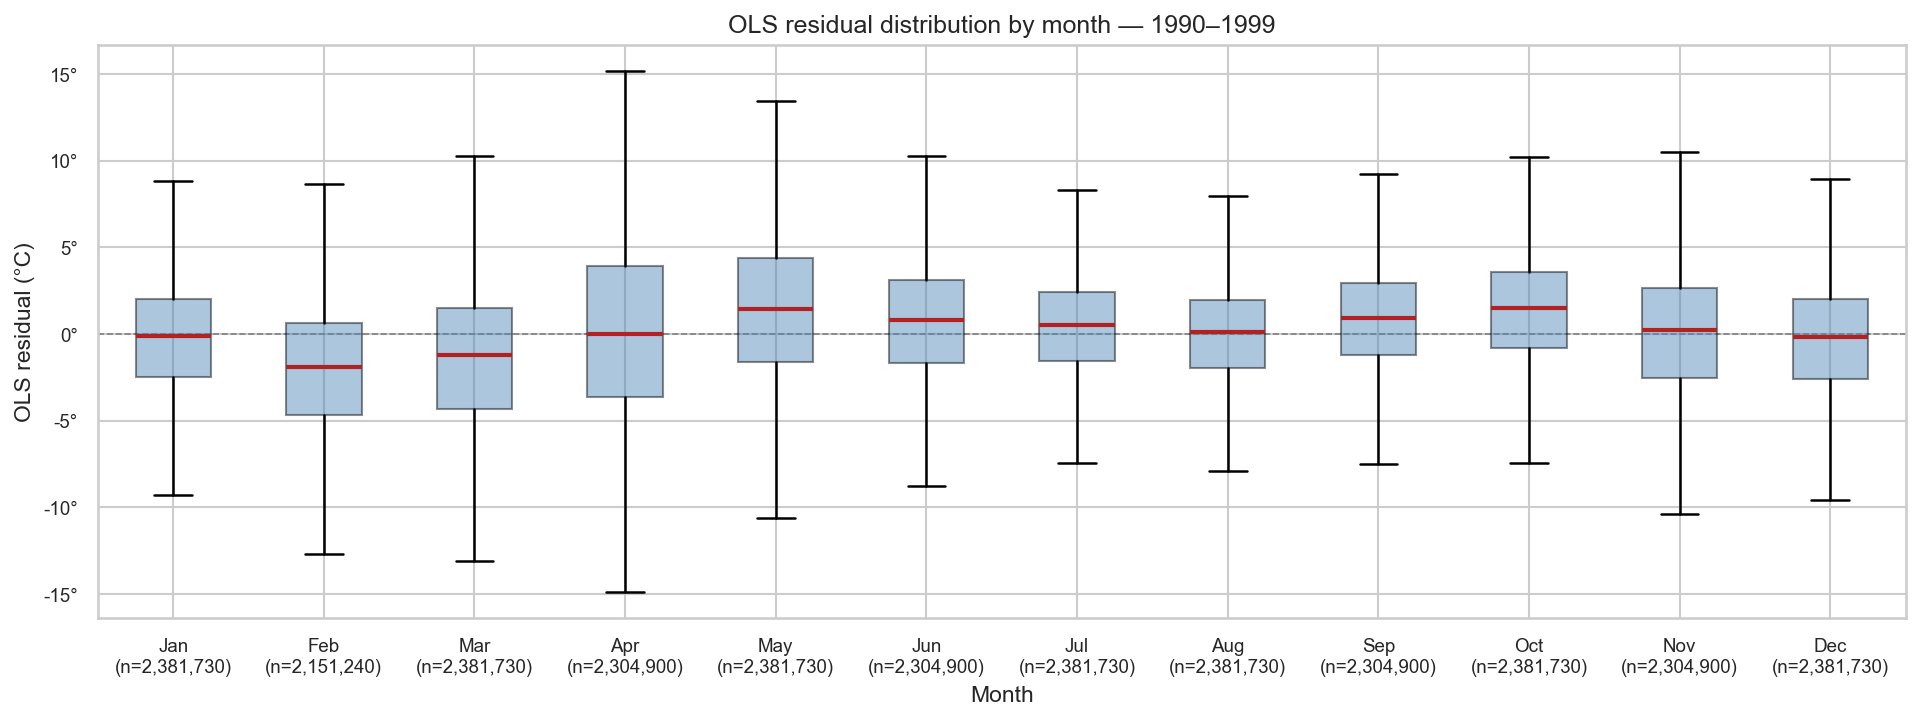

In [32]:
fig14 = viz.plot_residuals_by_month(
    resid_df=resid_df,
    title="OLS residual distribution by month — 1990–1999",
    save_path=PLOT_DIR / "fig14_residuals_by_month.png",
)
plt.show()


**Fig. 14.** OLS residual distribution by calendar month, 1990–1999. Each box summarises all pixel×day residuals for that month across the full study domain (Jan 1990 – Dec 1999, ~300 daily snapshots per month × 7,683 land pixels). Outliers are suppressed. A systematic pattern across months — for example, a cold bias in winter months and a warm bias in summer — would indicate that the global OLS slope is insufficient and that season-specific or non-linear models are needed. Data: ERA5-Land T2M and CMIP6 CESM2-WACCM TAS, 24–38°N, 30–38°E.

## 7. Feature Engineering Preview: Global Daily Mean Temperature  *(work in progress)*

As proposed by Dorita Morin, the area-weighted global mean daily TAS from the CMIP6 model provides a large-scale thermodynamic predictor that may improve the downscaling model beyond the local cell temperature alone. This section previews the global mean TAS time series; full integration into the model pipeline is planned for the next phase.

Global DS lat range: -90.0 → 90.0
Global DS lon range: -180.0 → 178.75


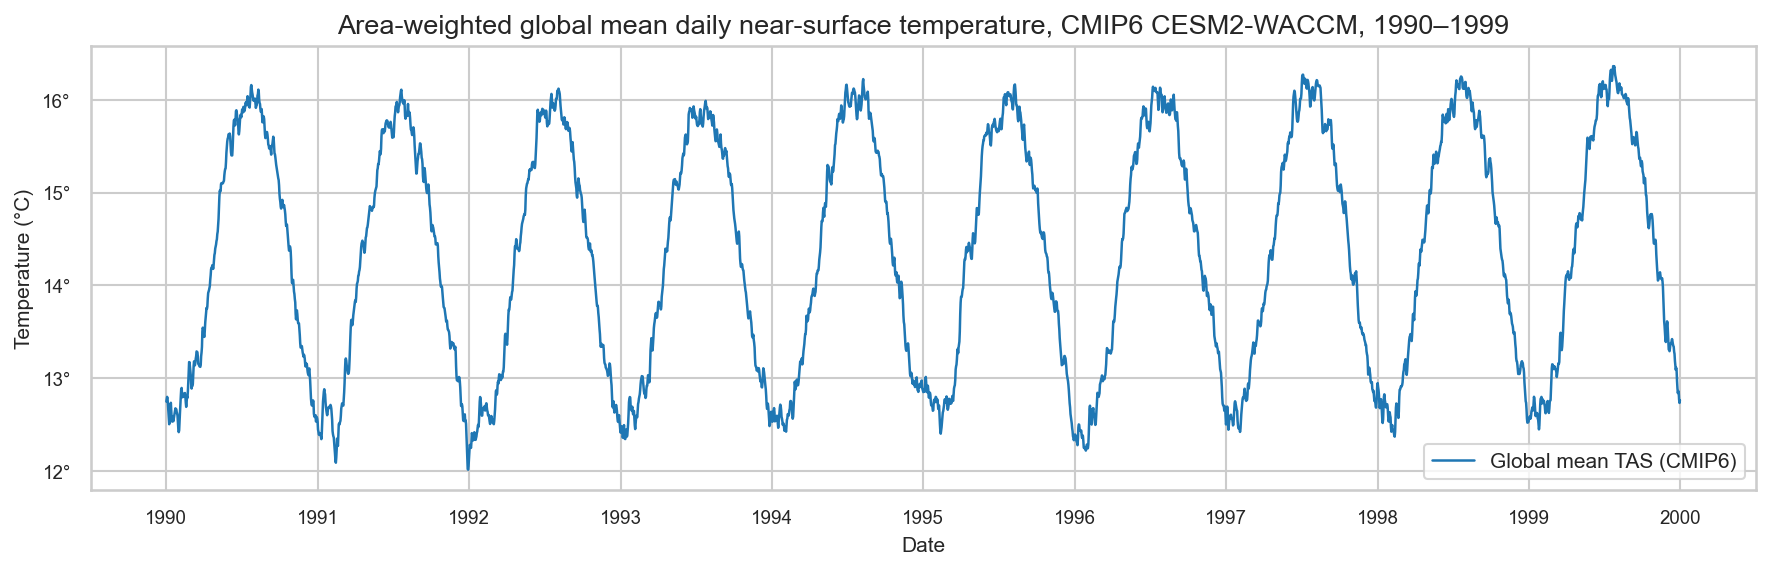

In [33]:
# Load the global CMIP6 file (full spatial extent) to compute global mean
cmip_global_ds = load_cmip6(CMIP_FILE, region=None)  # no spatial subsetting
# Verify the dataset is truly global
print('Global DS lat range:', float(cmip_global_ds.lat.min()), '→', float(cmip_global_ds.lat.max()))
print('Global DS lon range:', float(cmip_global_ds.lon.min()), '→', float(cmip_global_ds.lon.max()))

global_mean_tas = compute_global_daily_mean(cmip_global_ds, var='tas')
global_mean_celsius = global_mean_tas - 273.15 if global_mean_tas.mean() > 100 else global_mean_tas

fig = viz.plot_domain_timeseries(
    {'Global mean TAS (CMIP6)': global_mean_celsius},
    title='Area-weighted global mean daily near-surface temperature, CMIP6 CESM2-WACCM, 1990–1999',
    ylabel='Temperature (°C)',
    save_path=PLOT_DIR / 'fig09_global_mean_tas.png',
)
plt.show()

**Fig. 9.** Area-weighted global mean daily near-surface air temperature (TAS) from the CMIP6 CESM2-WACCM historical simulation, 1990–1999. This quantity serves as a potential large-scale thermodynamic predictor in the downscaling models, capturing the global temperature state on each day independently of the regional signal. Data: CMIP6 CESM2-WACCM historical simulation, global domain.